# Quaternion Masterclass: From Complex Numbers to 3D Rotations

**What you'll learn:**
- Why rotation is fundamentally about geometry, not formulas
- How complex numbers elegantly encode 2D rotation
- Why quaternions are the natural extension to 3D
- How to use quaternions in physics simulations (MuJoCo)

**Prerequisites:**
- Basic Python and NumPy
- High school trigonometry (sin, cos)
- Curiosity about how rotation really works

In [1]:
# =============================================================================
# ALL IMPORTS (STRC-02: centralized in first code cell)
# =============================================================================
# Standard library
import cmath
from typing import Tuple, List

# Scientific computing
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Arc
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

# Interactive widgets (STRC-03)
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# 3D rotation tools (Phase 2+)
from scipy.spatial.transform import Rotation as R
from scipy.spatial.transform import Slerp

# MuJoCo physics simulation (Phase 5)
import mujoco
import mediapy as media

# Enable interactive matplotlib backend - MUST be before any plotting
%matplotlib widget

print("All imports successful! Interactive matplotlib backend enabled.")

All imports successful! Interactive matplotlib backend enabled.


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
# Plotting defaults
plt.rcParams['figure.figsize'] = [6, 6]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True

# Constants
UNIT_CIRCLE_RADIUS = 1.0
DEFAULT_FIGSIZE = (6, 6)

print("Configuration loaded.")

Configuration loaded.


---
# Part 1: What IS Rotation?

Before we dive into formulas, let's build intuition for what rotation actually *is* as a geometric transformation.

## The Geometry of Rotation

**Rotation is a transformation that:**
1. **Preserves distances** - Points stay the same distance from the center
2. **Preserves shape** - A triangle stays a triangle, angles unchanged
3. **Changes orientation** - Points move around the center by the same angle

Think of it like a record player: every point on the vinyl moves in a circle around the center spindle. Points near the edge travel farther, but they all complete one rotation in the same time.

**Key insight:** Rotation is completely defined by:
- A **center point** (where's the spindle?)
- An **angle** (how far to rotate?)
- A **direction** (clockwise or counterclockwise?)

For now, we'll always rotate around the origin (0, 0). This simplifies everything.

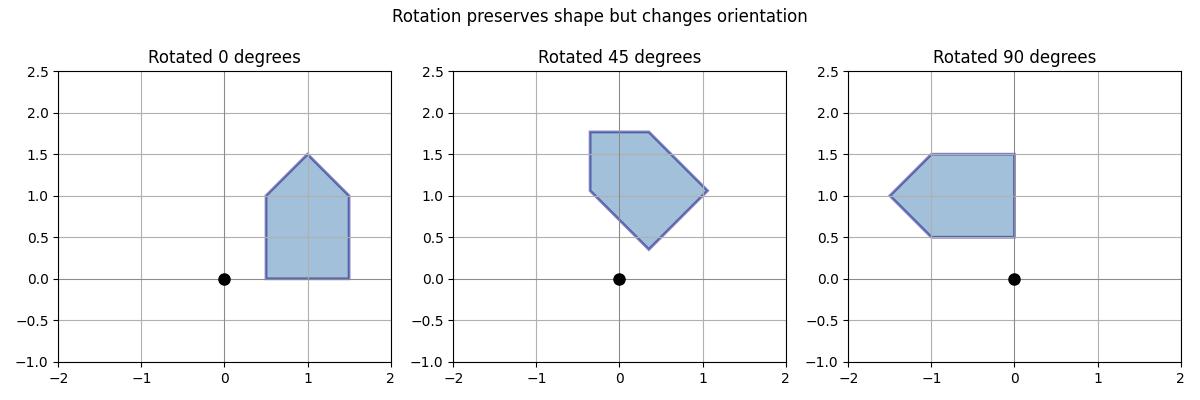

In [3]:
# Visualize what rotation DOES before explaining HOW
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# A simple shape: a house
house_x = [0.5, 0.5, 1.0, 1.5, 1.5, 0.5]
house_y = [0, 1.0, 1.5, 1.0, 0, 0]

# Convert to complex numbers for rotation (we'll explain this later!)
house_points = [complex(x, y) for x, y in zip(house_x, house_y)]

angles = [0, 45, 90]
for ax, angle_deg in zip(axes, angles):
    theta = np.radians(angle_deg)
    rotated = [z * cmath.exp(1j * theta) for z in house_points]

    rx = [z.real for z in rotated]
    ry = [z.imag for z in rotated]

    ax.fill(rx, ry, alpha=0.5, color='steelblue', edgecolor='navy', linewidth=2)
    ax.plot(0, 0, 'ko', markersize=8)  # Center point
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 2.5)
    ax.set_aspect('equal')
    ax.set_title(f'Rotated {angle_deg} degrees')
    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)

plt.suptitle('Rotation preserves shape but changes orientation', fontsize=12)
plt.tight_layout()
plt.show()

## The Challenge: How Do We *Compute* Rotation?

We've seen what rotation does. Now we need a way to calculate it.

Given a point at position (x, y) and an angle theta, where does the point end up?

**The traditional approach:** Trigonometry and rotation matrices
```
x' = x*cos(theta) - y*sin(theta)
y' = x*sin(theta) + y*cos(theta)
```

This works, but it's not intuitive. Why these particular combinations of sin and cos?

**A better approach:** Complex numbers

It turns out there's an elegant way to represent rotation using complex numbers, where the "why" becomes crystal clear. Let's discover it.

---
# Part 2: Complex Numbers as 2D Rotation Tools

Complex numbers aren't just "imaginary" - they're a powerful way to represent 2D points and rotations.

## Complex Numbers = 2D Vectors

A complex number z = a + bi can be visualized as a point (a, b) in 2D:
- **Real part (a):** The x-coordinate
- **Imaginary part (b):** The y-coordinate

The same point can be written in **polar form:**
- z = r * e^(i*theta)
- where r = distance from origin (magnitude)
- and theta = angle from positive x-axis (argument)

This polar form is the key to understanding rotation!

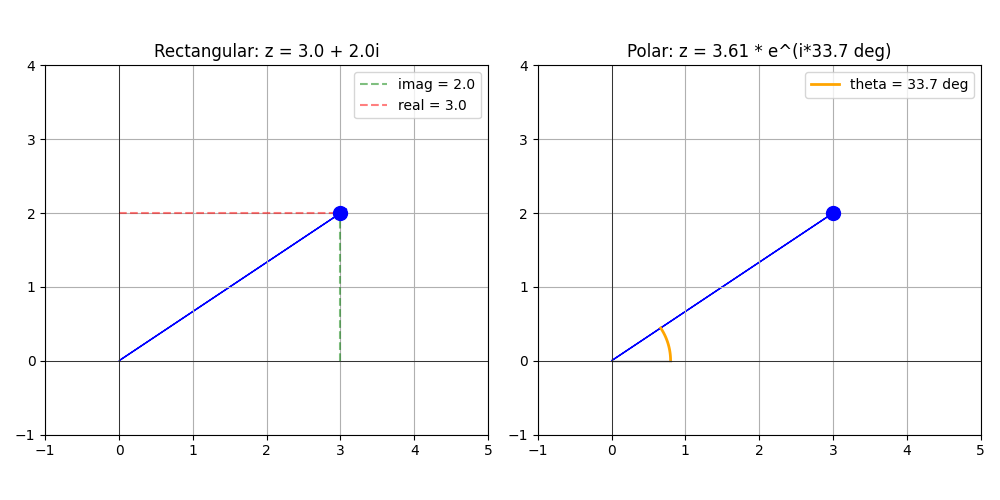

In [4]:
# Visualize complex numbers in both rectangular and polar form
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Example complex number
z = complex(3, 2)
r = abs(z)
theta = cmath.phase(z)

# Rectangular view
ax1.set_title(f'Rectangular: z = {z.real:.1f} + {z.imag:.1f}i')
ax1.arrow(0, 0, z.real, z.imag, head_width=0.15, head_length=0.1, fc='blue', ec='blue')
ax1.plot([z.real, z.real], [0, z.imag], 'g--', alpha=0.5, label=f'imag = {z.imag:.1f}')
ax1.plot([0, z.real], [z.imag, z.imag], 'r--', alpha=0.5, label=f'real = {z.real:.1f}')
ax1.plot(z.real, z.imag, 'bo', markersize=10)
ax1.set_xlim(-1, 5)
ax1.set_ylim(-1, 4)
ax1.set_aspect('equal')
ax1.legend()
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

# Polar view
ax2.set_title(f'Polar: z = {r:.2f} * e^(i*{np.degrees(theta):.1f} deg)')
ax2.arrow(0, 0, z.real, z.imag, head_width=0.15, head_length=0.1, fc='blue', ec='blue')
arc_angles = np.linspace(0, theta, 30)
arc_r = 0.8
ax2.plot(arc_r * np.cos(arc_angles), arc_r * np.sin(arc_angles), 'orange', linewidth=2, label=f'theta = {np.degrees(theta):.1f} deg')
ax2.plot([0, arc_r * np.cos(0)], [0, 0], 'gray', linewidth=1)
ax2.plot(z.real, z.imag, 'bo', markersize=10)
ax2.set_xlim(-1, 5)
ax2.set_ylim(-1, 4)
ax2.set_aspect('equal')
ax2.legend()
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

## The Magic of Multiplication

Here's the beautiful insight: **when you multiply two complex numbers in polar form, you add their angles!**

If z1 = r1 * e^(i*theta1) and z2 = r2 * e^(i*theta2), then:

**z1 * z2 = (r1 * r2) * e^(i*(theta1 + theta2))**

This means multiplying by e^(i*theta) (which has r=1) **rotates without scaling**!

Let's see this in action with an interactive demo.

---
## Interactive Demo: 2D Rotation via Complex Multiplication

Use the slider to rotate a point around the origin. Watch how multiplying by e^(i*theta) moves the point along the unit circle.

FloatSlider(value=0.0, description='Angle (deg):', layout=Layout(width='400px'), max=360.0, readout_format='.0…

Drag the slider to rotate the point!


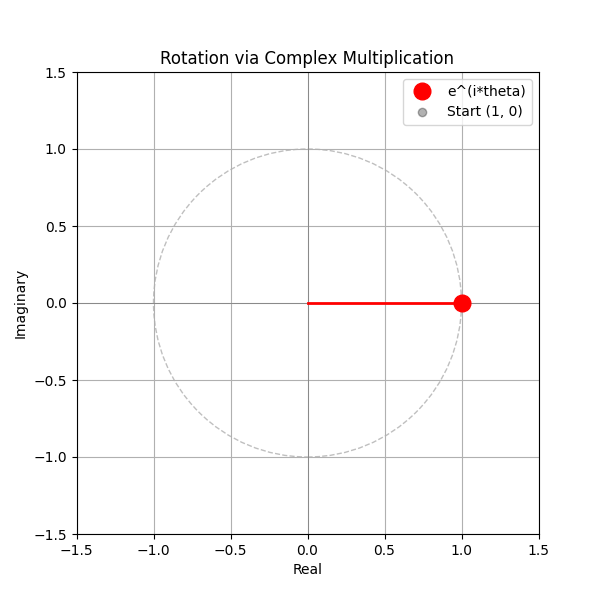

In [5]:
# Interactive 2D Rotation Demo (FOUND-02)
# Pattern: Create figure once, update elements via set_data (avoids flicker)

# Create figure with unit circle
rot_fig, rot_ax = plt.subplots(figsize=(6, 6))
rot_ax.set_xlim(-1.5, 1.5)
rot_ax.set_ylim(-1.5, 1.5)
rot_ax.set_aspect('equal')
rot_ax.set_xlabel('Real')
rot_ax.set_ylabel('Imaginary')
rot_ax.set_title('Rotation via Complex Multiplication')
rot_ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
rot_ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)

# Add unit circle (points on this circle have magnitude 1)
unit_circle = Circle((0, 0), UNIT_CIRCLE_RADIUS, fill=False, color='gray', linestyle='--', alpha=0.5)
rot_ax.add_patch(unit_circle)

# Initial point at (1, 0) - on the unit circle
rot_point, = rot_ax.plot([1], [0], 'ro', markersize=12, label='e^(i*theta)', zorder=5)
rot_vector, = rot_ax.plot([0, 1], [0, 0], 'r-', linewidth=2, zorder=4)

# Arc showing the angle
rot_arc, = rot_ax.plot([], [], 'b-', linewidth=2, alpha=0.7)

# Text annotations
rot_angle_text = rot_ax.text(-1.4, 1.3, '', fontsize=11, family='monospace')
rot_coords_text = rot_ax.text(-1.4, 1.1, '', fontsize=10)
rot_euler_text = rot_ax.text(-1.4, -1.4, '', fontsize=10)

# Mark original position
rot_ax.plot([1], [0], 'ko', markersize=6, alpha=0.3, label='Start (1, 0)')
rot_ax.legend(loc='upper right')

def update_rotation(angle_degrees):
    """Update visualization when angle slider changes."""
    theta = np.radians(angle_degrees)

    # Rotation using Euler's formula: e^(i*theta)
    z = cmath.exp(1j * theta)
    x, y = z.real, z.imag

    # Update point and vector (no figure recreation!)
    rot_point.set_data([x], [y])
    rot_vector.set_data([0, x], [0, y])

    # Update arc showing the angle
    if angle_degrees > 0:
        arc_angles = np.linspace(0, theta, max(2, int(angle_degrees)))
        arc_x = 0.3 * np.cos(arc_angles)
        arc_y = 0.3 * np.sin(arc_angles)
        rot_arc.set_data(arc_x, arc_y)
    else:
        rot_arc.set_data([], [])

    # Update text annotations
    rot_angle_text.set_text(f'theta = {angle_degrees:.0f} deg = {theta:.3f} rad')
    rot_coords_text.set_text(f'Position: ({x:.3f}, {y:.3f})')
    rot_euler_text.set_text(f'e^(i*{angle_degrees:.0f} deg) = {z.real:.3f} + {z.imag:.3f}i\n'
                           f'           = cos({angle_degrees:.0f} deg) + i*sin({angle_degrees:.0f} deg)')

    rot_fig.canvas.draw_idle()

# Create slider with continuous updates
angle_slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=360,
    step=1,
    description='Angle (deg):',
    continuous_update=True,
    readout_format='.0f',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

# Connect slider to update function
angle_slider.observe(lambda change: update_rotation(change['new']), names='value')

# Display slider above the figure
display(angle_slider)
print("Drag the slider to rotate the point!")

**Try these experiments:**
1. Set angle to **90 degrees** - where does the point land? (Answer: at i, position (0, 1))
2. Set angle to **180 degrees** - this is multiplying by -1!
3. Set angle to **270 degrees** - this is multiplying by -i
4. Notice how the point stays ON the unit circle - rotation preserves distance!

**Key insight:** The slider is literally multiplying (1, 0) by e^(i*theta). Every angle gives a different point on the unit circle.

---
# Part 3: WHY Does Complex Multiplication Rotate?

We've seen that multiplying by e^(i*theta) rotates. But *why*? Let's derive this from first principles.

## The Key Insight: Imaginary Growth = Perpendicular Push

Euler's formula states: **e^(i*theta) = cos(theta) + i*sin(theta)**

But where does this come from? The answer lies in understanding what "imaginary growth" means.

### Regular Exponential Growth

When you have e^x, you're describing continuous growth where the rate of change is proportional to the current value:
- At position 1, you grow by rate 1
- At position 2, you grow by rate 2
- The growth always pushes you *further from zero*

### Imaginary Exponential Growth (e^(i*theta))

What happens when the growth rate is *imaginary* (i)?

Multiplying by i rotates a number 90 degrees:
- 1 * i = i (pointing up)
- i * i = -1 (pointing left)
- -1 * i = -i (pointing down)
- -i * i = 1 (pointing right)

So imaginary growth pushes you **perpendicular to your current position**!

When you're always being pushed perpendicular to where you are, you move in a **circle**.

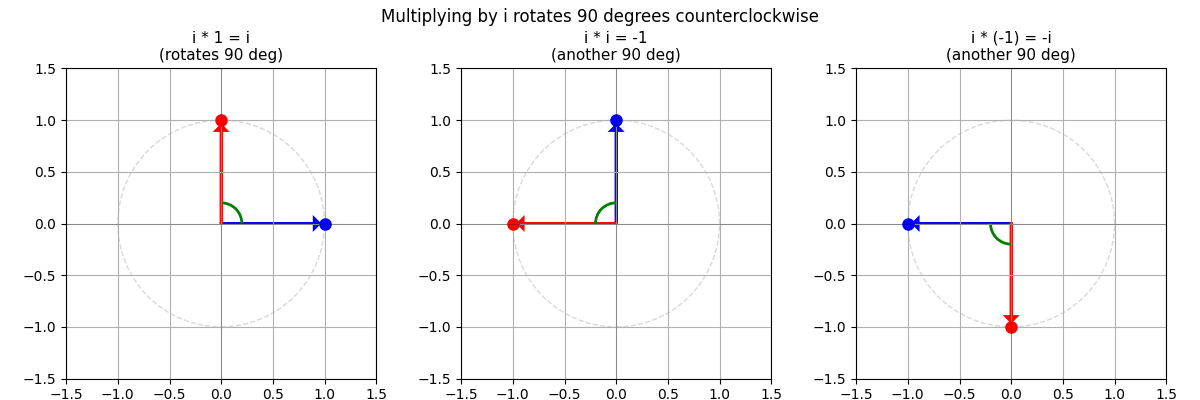

In [6]:
# Visualize: imaginary growth pushes perpendicular to position
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Show how i rotates things 90 degrees
examples = [
    (1, 'i', 'i * 1 = i\n(rotates 90 deg)'),
    (1j, '-1', 'i * i = -1\n(another 90 deg)'),
    (-1, '-i', 'i * (-1) = -i\n(another 90 deg)')
]

for ax, (start, end_label, title) in zip(axes, examples):
    start_z = complex(start)
    end_z = start_z * 1j

    # Draw unit circle
    circle = Circle((0, 0), 1, fill=False, color='gray', linestyle='--', alpha=0.3)
    ax.add_patch(circle)

    # Draw start vector
    ax.arrow(0, 0, start_z.real*0.9, start_z.imag*0.9, head_width=0.1,
             head_length=0.05, fc='blue', ec='blue', linewidth=2)
    ax.plot(start_z.real, start_z.imag, 'bo', markersize=8)

    # Draw end vector
    ax.arrow(0, 0, end_z.real*0.9, end_z.imag*0.9, head_width=0.1,
             head_length=0.05, fc='red', ec='red', linewidth=2)
    ax.plot(end_z.real, end_z.imag, 'ro', markersize=8)

    # Draw arc showing 90 degree rotation
    arc = Arc((0, 0), 0.4, 0.4,
              angle=0,
              theta1=np.degrees(cmath.phase(start_z)),
              theta2=np.degrees(cmath.phase(end_z)) if cmath.phase(end_z) > cmath.phase(start_z) else np.degrees(cmath.phase(end_z)) + 360,
              color='green', linewidth=2)
    ax.add_patch(arc)

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)

plt.suptitle('Multiplying by i rotates 90 degrees counterclockwise', fontsize=12)
plt.tight_layout()
plt.show()

## Putting It Together: Why e^(i*theta) = cos(theta) + i*sin(theta)

If imaginary growth pushes perpendicular, and perpendicular push creates circular motion, then:

1. **Starting at 1** (position (1, 0) on the real axis)
2. **Growing by rate i** (perpendicular to current position)
3. **For "time" theta** (the angle in radians)
4. **You end up at** the point theta radians around the unit circle

That point has coordinates **(cos(theta), sin(theta))** - this is just the definition of sine and cosine!

So: **e^(i*theta) = cos(theta) + i*sin(theta)**

This is Euler's formula, and it's not magic - it's the natural result of "growing perpendicularly creates circular motion."

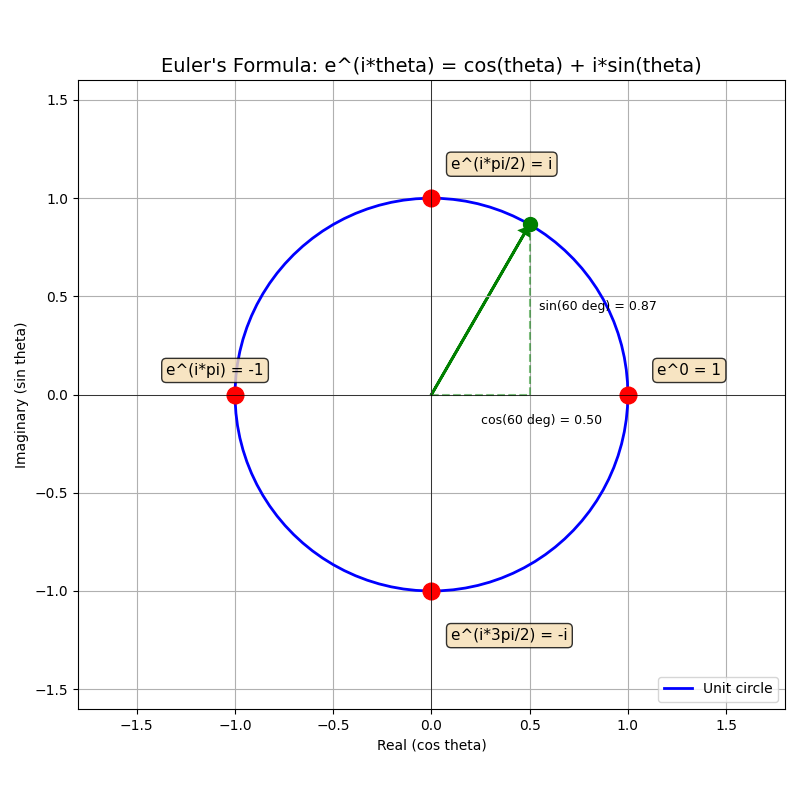

In [7]:
# Euler's Formula: e^(i*theta) traces the unit circle
fig, ax = plt.subplots(figsize=(8, 8))

# Draw unit circle
angles = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(angles), np.sin(angles), 'b-', linewidth=2, label='Unit circle')

# Mark key points with Euler's formula
key_points = [
    (0, 'e^0 = 1', (1.15, 0.1)),
    (np.pi/2, 'e^(i*pi/2) = i', (0.1, 1.15)),
    (np.pi, 'e^(i*pi) = -1', (-1.35, 0.1)),
    (3*np.pi/2, 'e^(i*3pi/2) = -i', (0.1, -1.25))
]

for theta, label, text_pos in key_points:
    z = cmath.exp(1j * theta)
    ax.plot(z.real, z.imag, 'ro', markersize=12)
    ax.annotate(label, text_pos, fontsize=11,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Show a general point
theta_example = np.pi/3  # 60 degrees
z_example = cmath.exp(1j * theta_example)
ax.arrow(0, 0, z_example.real*0.95, z_example.imag*0.95,
         head_width=0.05, head_length=0.03, fc='green', ec='green', linewidth=2)
ax.plot(z_example.real, z_example.imag, 'go', markersize=10)

# Show components
ax.plot([z_example.real, z_example.real], [0, z_example.imag], 'g--', alpha=0.5)
ax.plot([0, z_example.real], [0, 0], 'g--', alpha=0.5)
ax.text(z_example.real + 0.05, z_example.imag/2, f'sin(60 deg) = {z_example.imag:.2f}', fontsize=9)
ax.text(z_example.real/2, -0.15, f'cos(60 deg) = {z_example.real:.2f}', fontsize=9)

ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.6, 1.6)
ax.set_aspect('equal')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('Real (cos theta)')
ax.set_ylabel('Imaginary (sin theta)')
ax.set_title("Euler's Formula: e^(i*theta) = cos(theta) + i*sin(theta)", fontsize=14)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## Summary: Foundation

We've established the key ideas:

1. **Rotation is geometric** - it preserves distances and shapes while changing orientation
2. **Complex numbers are 2D vectors** - with magnitude and angle
3. **Multiplication adds angles** - so e^(i*theta) rotates by theta
4. **Euler's formula** - e^(i*theta) = cos(theta) + i*sin(theta) comes from "imaginary growth pushes perpendicular"

**Coming up next:** We'll see why Euler angles (the "obvious" way to do 3D rotation) have a fatal flaw called gimbal lock, and why we need quaternions.

---
# Part 4: Moving to 3D - Rotation Representations

In 2D, rotation is simple: just one angle around a single point. But 3D is fundamentally harder.

**Why 3D is more complex:**
- In 2D: one angle (rotate around a point)
- In 3D: need to specify rotation axis AND rotation amount
- More degrees of freedom = more ways to represent the same rotation

Let's explore the three most common ways to represent 3D rotations:
1. **Euler angles** - Three sequential rotations (yaw, pitch, roll)
2. **Rotation matrices** - 3x3 matrices that transform coordinates
3. **Axis-angle** - One axis vector plus one rotation angle

Each has trade-offs, and understanding them will help us see why quaternions are so useful.

## Euler Angles: Yaw, Pitch, Roll

Euler angles describe 3D rotation as three sequential rotations around coordinate axes:

- **Yaw (Z-axis):** Turn left/right, like shaking your head "no"
- **Pitch (Y-axis):** Tilt up/down, like nodding "yes"
- **Roll (X-axis):** Tilt side to side, like a plane banking

**Important:** The order matters! We use **intrinsic ZYX** (also called "Tait-Bryan angles"):
1. First rotate around Z (yaw)
2. Then around the new Y (pitch)
3. Finally around the new X (roll)

In scipy, intrinsic rotations use **uppercase** letters: `'ZYX'`

Let's visualize this with an interactive demo!

Drag the sliders to rotate the coordinate frame!
Try: Yaw=45 to turn right, Pitch=30 to look up, Roll=20 to tilt


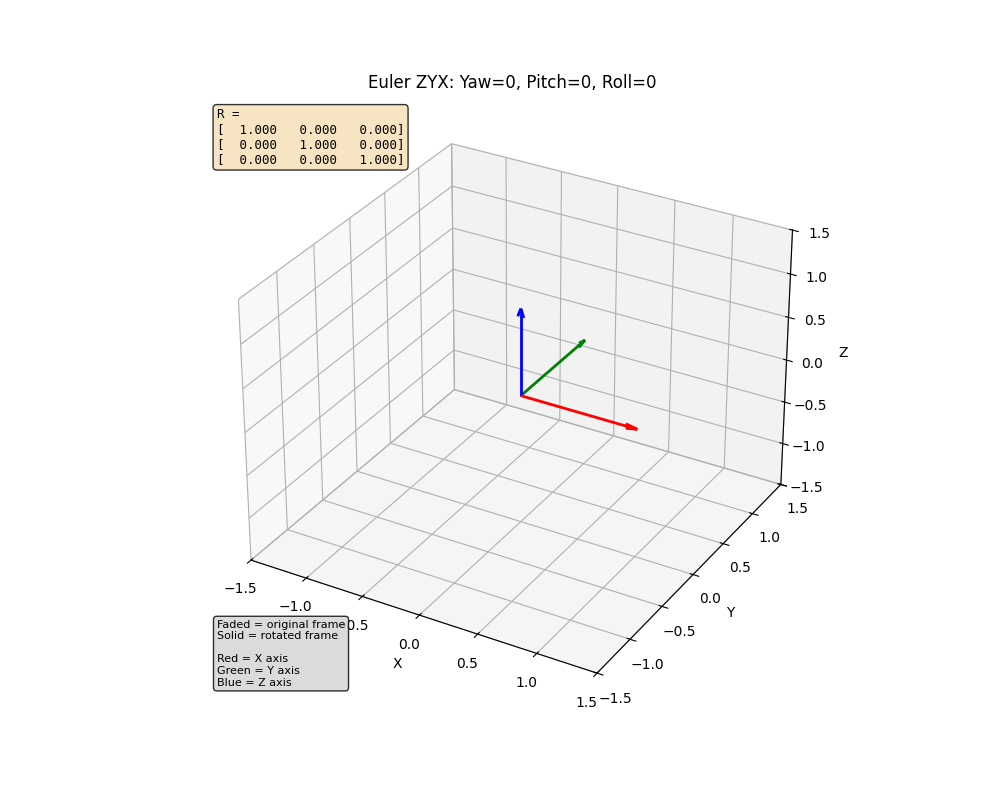

In [8]:
# =============================================================================
# Interactive Euler Angle Demo (REPR-01)
# Visualizes 3D coordinate frame rotation with yaw/pitch/roll sliders
# =============================================================================

def draw_coordinate_frame(ax, rotation_matrix, origin=(0, 0, 0), length=1.0, alpha=1.0):
    """Draw XYZ axes as RGB colored arrows."""
    colors = ['red', 'green', 'blue']
    labels = ['X', 'Y', 'Z']
    
    for i, (color, label) in enumerate(zip(colors, labels)):
        # Get rotated axis direction (column of rotation matrix)
        direction = rotation_matrix[:, i] * length
        ax.quiver(origin[0], origin[1], origin[2],
                  direction[0], direction[1], direction[2],
                  color=color, alpha=alpha, arrow_length_ratio=0.1,
                  linewidth=2 if alpha == 1.0 else 1)

def format_rotation_matrix(matrix):
    """Format rotation matrix as string for display."""
    return '\n'.join([
        f'[{matrix[0,0]:7.3f} {matrix[0,1]:7.3f} {matrix[0,2]:7.3f}]',
        f'[{matrix[1,0]:7.3f} {matrix[1,1]:7.3f} {matrix[1,2]:7.3f}]',
        f'[{matrix[2,0]:7.3f} {matrix[2,1]:7.3f} {matrix[2,2]:7.3f}]'
    ])

# Create figure
euler_fig = plt.figure(figsize=(10, 8))
euler_ax = euler_fig.add_subplot(111, projection='3d')

def update_euler_demo(yaw, pitch, roll):
    """Update 3D coordinate frame based on Euler angles."""
    euler_ax.cla()
    
    # Create rotation from Euler angles (intrinsic ZYX = yaw, pitch, roll)
    rot = R.from_euler('ZYX', [yaw, pitch, roll], degrees=True)
    matrix = rot.as_matrix()
    
    # Draw original frame (faded)
    draw_coordinate_frame(euler_ax, np.eye(3), alpha=0.2)
    
    # Draw rotated frame
    draw_coordinate_frame(euler_ax, matrix)
    
    # Set consistent view
    euler_ax.set_xlim([-1.5, 1.5])
    euler_ax.set_ylim([-1.5, 1.5])
    euler_ax.set_zlim([-1.5, 1.5])
    euler_ax.set_xlabel('X')
    euler_ax.set_ylabel('Y')
    euler_ax.set_zlabel('Z')
    euler_ax.set_title(f'Euler ZYX: Yaw={yaw:.0f}, Pitch={pitch:.0f}, Roll={roll:.0f}')
    
    # Show rotation matrix as text
    matrix_str = f'R =\n{format_rotation_matrix(matrix)}'
    euler_ax.text2D(0.02, 0.98, matrix_str, transform=euler_ax.transAxes,
                    fontfamily='monospace', fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Add legend for axes colors
    euler_ax.text2D(0.02, 0.15, 'Faded = original frame\nSolid = rotated frame\n\nRed = X axis\nGreen = Y axis\nBlue = Z axis',
                    transform=euler_ax.transAxes, fontsize=8, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    euler_fig.canvas.draw_idle()

# Create sliders
euler_yaw_slider = widgets.FloatSlider(value=0, min=-180, max=180, step=1, description='Yaw (Z):')
euler_pitch_slider = widgets.FloatSlider(value=0, min=-90, max=90, step=1, description='Pitch (Y):')
euler_roll_slider = widgets.FloatSlider(value=0, min=-180, max=180, step=1, description='Roll (X):')

def on_euler_slider_change(change):
    update_euler_demo(
        euler_yaw_slider.value,
        euler_pitch_slider.value,
        euler_roll_slider.value
    )

for slider in [euler_yaw_slider, euler_pitch_slider, euler_roll_slider]:
    slider.observe(on_euler_slider_change, names='value')

# Display sliders
euler_sliders = widgets.VBox([euler_yaw_slider, euler_pitch_slider, euler_roll_slider])
display(euler_sliders)

# Initial draw
update_euler_demo(0, 0, 0)
print("Drag the sliders to rotate the coordinate frame!")
print("Try: Yaw=45 to turn right, Pitch=30 to look up, Roll=20 to tilt")

**Try these experiments:**
1. Set **Yaw = 90**: The X-axis (red) now points where Y used to be
2. Set **Pitch = 45**: The frame tilts forward
3. Set **Roll = 30**: The frame tilts sideways
4. Combine all three: Notice how the order matters - this is intrinsic rotation

**Watch the rotation matrix change!** Each value shows how the axes transform.

---
## Rotation Matrices: The Computer's Perspective

While Euler angles are intuitive for humans, computers use **rotation matrices** to actually transform points.

A rotation matrix R is a 3x3 matrix with special properties:
- **Orthogonal:** R^T = R^(-1) (transpose equals inverse)
- **Determinant = 1:** Preserves volume and handedness
- **Columns are unit vectors:** Each column is a unit-length direction

**The key insight: Each column shows where an original axis ends up!**
- Column 1 = where the X-axis points after rotation
- Column 2 = where the Y-axis points after rotation  
- Column 3 = where the Z-axis points after rotation

This is exactly what we're drawing with the colored arrows above!

In [9]:
# Demonstrate the geometric meaning of rotation matrix columns (REPR-02)
print("="*60)
print("ROTATION MATRIX = THE ROTATED COORDINATE FRAME")
print("="*60)

# Example rotation: 45 degree yaw, 30 degree pitch
example_rot = R.from_euler('ZYX', [45, 30, 0], degrees=True)
example_matrix = example_rot.as_matrix()

print(f"\nEuler angles: Yaw=45, Pitch=30, Roll=0")
print(f"\nRotation Matrix:")
print(f"      Column 1      Column 2      Column 3")
print(f"     (X goes to)   (Y goes to)   (Z goes to)")
print(f"     [{example_matrix[0,0]:7.3f}      {example_matrix[0,1]:7.3f}      {example_matrix[0,2]:7.3f}]")
print(f"R =  [{example_matrix[1,0]:7.3f}      {example_matrix[1,1]:7.3f}      {example_matrix[1,2]:7.3f}]")
print(f"     [{example_matrix[2,0]:7.3f}      {example_matrix[2,1]:7.3f}      {example_matrix[2,2]:7.3f}]")

print(f"\n" + "-"*60)
print("Geometric interpretation:")
print(f"  X-axis (red)   -> [{example_matrix[0,0]:.3f}, {example_matrix[1,0]:.3f}, {example_matrix[2,0]:.3f}]")
print(f"  Y-axis (green) -> [{example_matrix[0,1]:.3f}, {example_matrix[1,1]:.3f}, {example_matrix[2,1]:.3f}]")
print(f"  Z-axis (blue)  -> [{example_matrix[0,2]:.3f}, {example_matrix[1,2]:.3f}, {example_matrix[2,2]:.3f}]")

print(f"\nTo rotate a point v, just multiply: v' = R @ v")
print("="*60)

ROTATION MATRIX = THE ROTATED COORDINATE FRAME

Euler angles: Yaw=45, Pitch=30, Roll=0

Rotation Matrix:
      Column 1      Column 2      Column 3
     (X goes to)   (Y goes to)   (Z goes to)
     [  0.612       -0.707        0.354]
R =  [  0.612        0.707        0.354]
     [ -0.500       -0.000        0.866]

------------------------------------------------------------
Geometric interpretation:
  X-axis (red)   -> [0.612, 0.612, -0.500]
  Y-axis (green) -> [-0.707, 0.707, -0.000]
  Z-axis (blue)  -> [0.354, 0.354, 0.866]

To rotate a point v, just multiply: v' = R @ v


**Key insight:** The rotation matrix IS the rotated coordinate frame, encoded as column vectors.

When you see a rotation matrix, you can immediately visualize it:
- Read column 1: That's where the red arrow (X-axis) points
- Read column 2: That's where the green arrow (Y-axis) points
- Read column 3: That's where the blue arrow (Z-axis) points

This connection between matrices and visual frames is fundamental to understanding rotations!

---
## Axis-Angle: The Elegant Alternative

There's another way to describe 3D rotation that's often more intuitive: **axis-angle representation**.

**Any 3D rotation can be described as:**
- An **axis** (a unit vector showing what to rotate around)
- An **angle** (how much to rotate)

This is like describing how you'd rotate a physical object:
- "Rotate 90 degrees around the vertical" is clearer than "yaw=90, pitch=0, roll=0"
- "Rotate 45 degrees around a diagonal axis" is natural

**Scipy uses rotation vectors:** axis * angle_radians
- The direction is the axis
- The magnitude (length) is the angle in radians

This representation leads naturally to quaternions (as we'll see later)!

Set the axis direction, then change the angle to rotate around it!


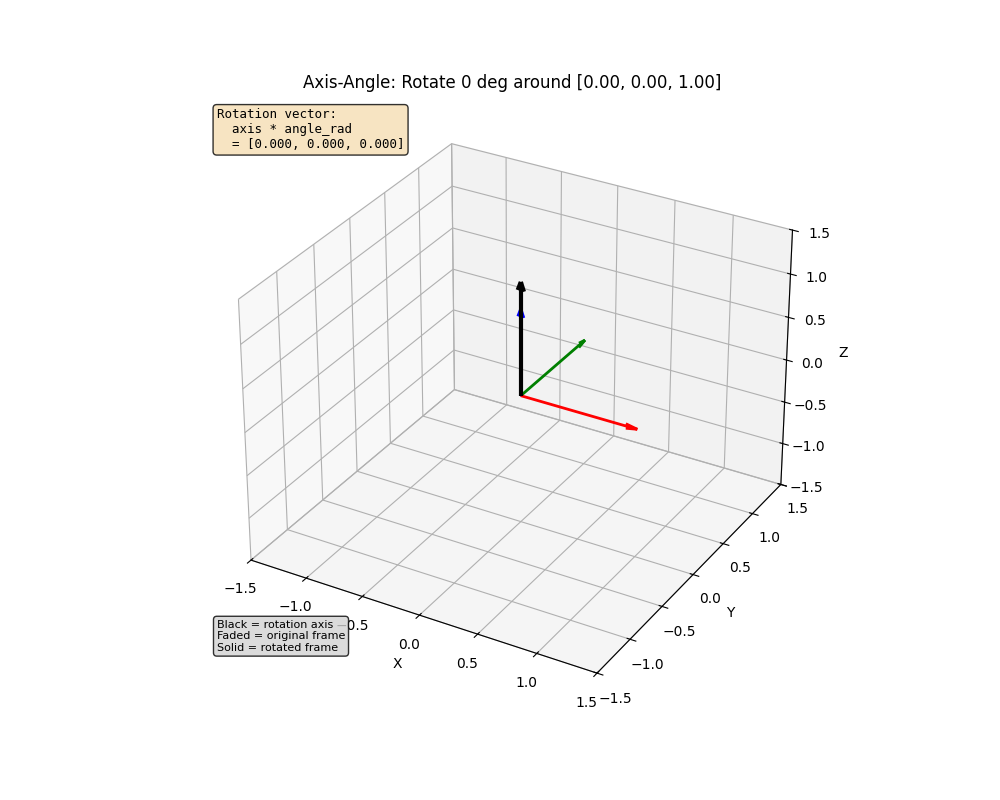

In [10]:
# =============================================================================
# Interactive Axis-Angle Demo (REPR-03)
# Visualizes rotation as axis + angle
# =============================================================================

# Create figure
aa_fig = plt.figure(figsize=(10, 8))
aa_ax = aa_fig.add_subplot(111, projection='3d')

def update_axis_angle_demo(axis_x, axis_y, axis_z, angle_deg):
    """Update axis-angle visualization."""
    aa_ax.cla()
    
    # Handle zero axis case
    axis = np.array([axis_x, axis_y, axis_z])
    axis_norm = np.linalg.norm(axis)
    if axis_norm < 0.01:
        axis = np.array([0, 0, 1])  # Default to Z axis
    else:
        axis = axis / axis_norm  # Normalize
    
    # Create rotation from axis-angle
    angle_rad = np.radians(angle_deg)
    rot = R.from_rotvec(axis * angle_rad)
    matrix = rot.as_matrix()
    
    # Draw rotation axis (thick black arrow)
    aa_ax.quiver(0, 0, 0, axis[0]*1.3, axis[1]*1.3, axis[2]*1.3,
                 color='black', linewidth=3, arrow_length_ratio=0.08,
                 label=f'Axis [{axis[0]:.2f}, {axis[1]:.2f}, {axis[2]:.2f}]')
    
    # Draw original frame (faded)
    draw_coordinate_frame(aa_ax, np.eye(3), alpha=0.2)
    
    # Draw rotated frame
    draw_coordinate_frame(aa_ax, matrix)
    
    # Set consistent view
    aa_ax.set_xlim([-1.5, 1.5])
    aa_ax.set_ylim([-1.5, 1.5])
    aa_ax.set_zlim([-1.5, 1.5])
    aa_ax.set_xlabel('X')
    aa_ax.set_ylabel('Y')
    aa_ax.set_zlabel('Z')
    aa_ax.set_title(f'Axis-Angle: Rotate {angle_deg:.0f} deg around [{axis[0]:.2f}, {axis[1]:.2f}, {axis[2]:.2f}]')
    
    # Add info text
    aa_ax.text2D(0.02, 0.98, f'Rotation vector:\n  axis * angle_rad\n  = [{axis[0]*angle_rad:.3f}, {axis[1]*angle_rad:.3f}, {axis[2]*angle_rad:.3f}]',
                 transform=aa_ax.transAxes, fontfamily='monospace', fontsize=9,
                 verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Legend
    aa_ax.text2D(0.02, 0.15, 'Black = rotation axis\nFaded = original frame\nSolid = rotated frame',
                 transform=aa_ax.transAxes, fontsize=8, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    aa_fig.canvas.draw_idle()

# Create sliders for axis components and angle
axis_x_slider = widgets.FloatSlider(value=0, min=-1, max=1, step=0.1, description='Axis X:')
axis_y_slider = widgets.FloatSlider(value=0, min=-1, max=1, step=0.1, description='Axis Y:')
axis_z_slider = widgets.FloatSlider(value=1, min=-1, max=1, step=0.1, description='Axis Z:')
aa_angle_slider = widgets.FloatSlider(value=0, min=0, max=360, step=5, description='Angle (deg):')

def on_aa_slider_change(change):
    update_axis_angle_demo(
        axis_x_slider.value,
        axis_y_slider.value,
        axis_z_slider.value,
        aa_angle_slider.value
    )

for slider in [axis_x_slider, axis_y_slider, axis_z_slider, aa_angle_slider]:
    slider.observe(on_aa_slider_change, names='value')

# Display sliders
aa_sliders = widgets.VBox([
    widgets.HTML('<b>Rotation Axis (normalized automatically):</b>'),
    axis_x_slider, axis_y_slider, axis_z_slider,
    widgets.HTML('<b>Rotation Amount:</b>'),
    aa_angle_slider
])
display(aa_sliders)

# Initial draw
update_axis_angle_demo(0, 0, 1, 0)
print("Set the axis direction, then change the angle to rotate around it!")

**Try these experiments:**
1. **Z-axis rotation:** Set axis to [0, 0, 1], then rotate - this is pure yaw
2. **X-axis rotation:** Set axis to [1, 0, 0], then rotate - this is pure roll
3. **Diagonal rotation:** Set axis to [1, 1, 1], angle to 120 - watch XYZ cycle!
4. **Notice:** The black arrow shows WHAT you're rotating around

**Key insight:** Axis-angle is more intuitive for describing rotations verbally:
- "Rotate 90 degrees around the up direction" = axis [0,0,1], angle 90
- "Tip forward 30 degrees" = axis [1,0,0], angle 30

---
## Comparing the Three Representations

We've now seen three ways to represent the same 3D rotation:

| Representation | Parameters | Intuitive? | Used for? |
|---------------|------------|------------|------------|
| **Euler angles** | 3 angles (yaw, pitch, roll) | Yes - like head movement | Human input/display |
| **Rotation matrix** | 9 numbers (3x3) | No - but shows geometry | Transforming points |
| **Axis-angle** | 4 numbers (axis + angle) | Yes - single axis concept | Understanding rotation |

**All three describe the SAME rotation - just different encodings!**

But Euler angles have a serious problem that we'll discover next: **gimbal lock**.

And axis-angle leads naturally to **quaternions** - because if you think about it, a 3D rotation needs 4 numbers (axis direction has 2 DOF + 1 for angle = 3 DOF, but we encode it as unit quaternion with 4 components).

---
## The Gimbal Lock Problem

Euler angles have a critical flaw: **gimbal lock**.

**What is gimbal lock?**

Gimbal lock occurs when two rotation axes align, causing **loss of one degree of freedom**.

For our ZYX (yaw-pitch-roll) sequence:
- When pitch = +90 or -90 degrees, the yaw axis (Z) and roll axis (X) become **parallel**
- At this point, yaw and roll do the **exact same thing** - we've lost the ability to control one axis independently

Think of it this way:
- Normal: You have 3 independent knobs (yaw, pitch, roll) for 3 degrees of freedom
- Gimbal lock: Two knobs now do the same thing - only 2 independent controls for 3D rotation!

Let's see this happen with an interactive demo.

Set Pitch to 90 degrees to trigger gimbal lock!
Then wiggle Yaw and Roll - notice they do the SAME thing!


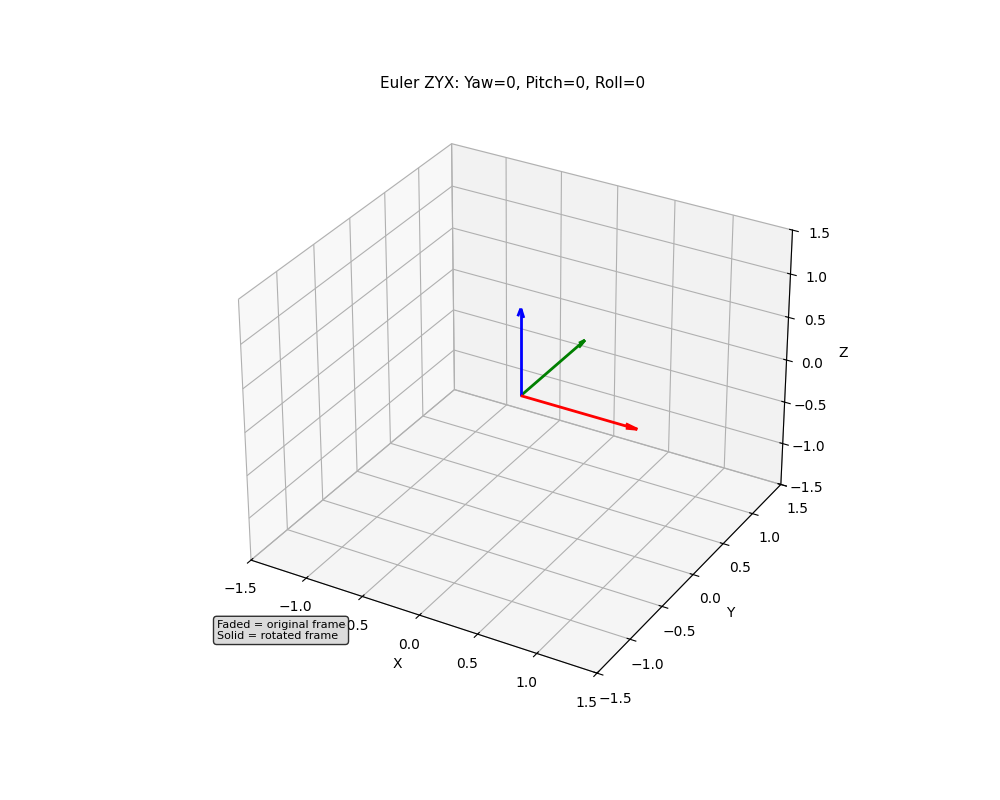

In [11]:
# =============================================================================
# Gimbal Lock Interactive Demo (GMBL-01, GMBL-02)
# Shows loss of degree of freedom at pitch = +/- 90 degrees
# =============================================================================

def check_gimbal_lock(pitch_degrees, tolerance=2):
    """Check if pitch angle is near gimbal lock condition.
    
    Gimbal lock occurs when pitch = +/-90 degrees for ZYX sequence.
    Returns True if within tolerance of 90 or -90.
    """
    return abs(abs(pitch_degrees) - 90) < tolerance

# Create figure for gimbal lock demo
gimbal_fig = plt.figure(figsize=(10, 8))
gimbal_ax = gimbal_fig.add_subplot(111, projection='3d')

# Status indicator widget
gimbal_status = widgets.HTML(
    value='<span style="color: green; font-size: 14px; font-weight: bold;">Status: Normal - 3 degrees of freedom</span>'
)

def update_gimbal_demo(yaw, pitch, roll):
    """Update gimbal lock visualization."""
    gimbal_ax.cla()
    
    # Check for gimbal lock
    is_locked = check_gimbal_lock(pitch)
    
    # Create rotation from Euler angles
    rot = R.from_euler('ZYX', [yaw, pitch, roll], degrees=True)
    matrix = rot.as_matrix()
    
    # Draw original frame (faded)
    draw_coordinate_frame(gimbal_ax, np.eye(3), alpha=0.2)
    
    # Draw rotated frame
    draw_coordinate_frame(gimbal_ax, matrix)
    
    # Set consistent view
    gimbal_ax.set_xlim([-1.5, 1.5])
    gimbal_ax.set_ylim([-1.5, 1.5])
    gimbal_ax.set_zlim([-1.5, 1.5])
    gimbal_ax.set_xlabel('X')
    gimbal_ax.set_ylabel('Y')
    gimbal_ax.set_zlabel('Z')
    
    # Update title and status based on gimbal lock
    if is_locked:
        # Calculate effective angle (yaw and roll combine)
        if pitch > 0:
            effective = yaw + roll
        else:
            effective = yaw - roll
        
        gimbal_ax.set_title(
            f'GIMBAL LOCK!\n'
            f'Yaw={yaw:.0f} + Roll={roll:.0f} = {effective:.0f} deg effective rotation',
            color='red', fontweight='bold', fontsize=12
        )
        gimbal_status.value = (
            '<span style="color: red; font-size: 16px; font-weight: bold;">'
            'GIMBAL LOCK! Yaw and Roll now do the SAME thing!</span><br>'
            f'<span style="color: red;">Effective angle: {effective:.0f} degrees</span>'
        )
    else:
        gimbal_ax.set_title(
            f'Euler ZYX: Yaw={yaw:.0f}, Pitch={pitch:.0f}, Roll={roll:.0f}',
            fontsize=11
        )
        gimbal_status.value = (
            '<span style="color: green; font-size: 14px; font-weight: bold;">'
            'Status: Normal - 3 degrees of freedom</span>'
        )
    
    # Info text
    gimbal_ax.text2D(0.02, 0.15, 'Faded = original frame\nSolid = rotated frame',
                     transform=gimbal_ax.transAxes, fontsize=8, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    gimbal_fig.canvas.draw_idle()

# Create sliders
gimbal_yaw_slider = widgets.FloatSlider(value=0, min=-180, max=180, step=1, description='Yaw (Z):')
gimbal_pitch_slider = widgets.FloatSlider(value=0, min=-90, max=90, step=1, description='Pitch (Y):')
gimbal_roll_slider = widgets.FloatSlider(value=0, min=-180, max=180, step=1, description='Roll (X):')

def on_gimbal_slider_change(change):
    update_gimbal_demo(
        gimbal_yaw_slider.value,
        gimbal_pitch_slider.value,
        gimbal_roll_slider.value
    )

for slider in [gimbal_yaw_slider, gimbal_pitch_slider, gimbal_roll_slider]:
    slider.observe(on_gimbal_slider_change, names='value')

# Display widgets
gimbal_controls = widgets.VBox([
    gimbal_status,
    gimbal_yaw_slider,
    gimbal_pitch_slider,
    gimbal_roll_slider
])
display(gimbal_controls)

# Initial draw
update_gimbal_demo(0, 0, 0)
print("Set Pitch to 90 degrees to trigger gimbal lock!")
print("Then wiggle Yaw and Roll - notice they do the SAME thing!")

### Try It Yourself: Triggering Gimbal Lock

1. **Set Pitch to exactly 90 degrees** - Watch the status turn red
2. **Now wiggle the Yaw slider** - Watch the frame rotate
3. **Now wiggle the Roll slider** - It does the SAME rotation!
4. **This is gimbal lock:** Two controls have become one. We lost a degree of freedom.

**The math behind it:**
- At pitch = 90, the frame is pointing straight up (or down)
- Yaw rotates around world Z, Roll rotates around (now vertical) body X
- But both axes are now parallel - they do the same thing!
- Yaw + Roll = one effective rotation angle

In [12]:
# =============================================================================
# Mathematical Proof of Gimbal Lock
# Shows that different Euler angles can produce identical rotations
# =============================================================================

print("="*70)
print("MATHEMATICAL PROOF: GIMBAL LOCK")
print("="*70)
print("\nAt pitch = 90 degrees, yaw and roll COMBINE into a single rotation.")
print("Different Euler angle combinations produce the SAME rotation matrix!\n")

# Three different Euler angle combinations that should produce different rotations...
# But at pitch = 90, they all produce the SAME rotation!
test_cases = [
    (30, 90, 0),   # Yaw=30, Pitch=90, Roll=0  -> Yaw + Roll = 30
    (20, 90, 10),  # Yaw=20, Pitch=90, Roll=10 -> Yaw + Roll = 30
    (10, 90, 20),  # Yaw=10, Pitch=90, Roll=20 -> Yaw + Roll = 30
    (0, 90, 30),   # Yaw=0,  Pitch=90, Roll=30 -> Yaw + Roll = 30
]

print("Euler Angles (Yaw, Pitch, Roll)    ->  Rotation Matrix (first row)")
print("-"*70)

matrices = []
for yaw, pitch, roll in test_cases:
    rot = R.from_euler('ZYX', [yaw, pitch, roll], degrees=True)
    matrix = rot.as_matrix()
    matrices.append(matrix)
    
    print(f"({yaw:3.0f}, {pitch:2.0f}, {roll:2.0f})  Yaw+Roll={yaw+roll:3.0f}   "
          f"-> [{matrix[0,0]:7.4f}, {matrix[0,1]:7.4f}, {matrix[0,2]:7.4f}]")

print("-"*70)
print("\nNotice: All four rotation matrices are IDENTICAL!")
print("This proves that at pitch=90, only (Yaw + Roll) matters.")
print("We've lost one degree of freedom - that's gimbal lock.\n")

# Verify they're truly identical
print("Verification - Maximum difference between matrices:")
for i in range(1, len(matrices)):
    diff = np.max(np.abs(matrices[0] - matrices[i]))
    print(f"  Case 1 vs Case {i+1}: {diff:.2e}")

print("\n" + "="*70)

MATHEMATICAL PROOF: GIMBAL LOCK

At pitch = 90 degrees, yaw and roll COMBINE into a single rotation.
Different Euler angle combinations produce the SAME rotation matrix!

Euler Angles (Yaw, Pitch, Roll)    ->  Rotation Matrix (first row)
----------------------------------------------------------------------
( 30, 90,  0)  Yaw+Roll= 30   -> [ 0.0000, -0.5000,  0.8660]
( 20, 90, 10)  Yaw+Roll= 30   -> [ 0.0000, -0.1736,  0.9848]
( 10, 90, 20)  Yaw+Roll= 30   -> [ 0.0000,  0.1736,  0.9848]
(  0, 90, 30)  Yaw+Roll= 30   -> [ 0.0000,  0.5000,  0.8660]
----------------------------------------------------------------------

Notice: All four rotation matrices are IDENTICAL!
This proves that at pitch=90, only (Yaw + Roll) matters.
We've lost one degree of freedom - that's gimbal lock.

Verification - Maximum difference between matrices:
  Case 1 vs Case 2: 3.26e-01
  Case 1 vs Case 3: 6.74e-01
  Case 1 vs Case 4: 1.00e+00



---
## Myth Busting: Quaternions and Gimbal Lock

**Common misconception:** "Just use quaternions and gimbal lock goes away!"

**THE TRUTH:** Gimbal lock is about **how you compose rotations**, not **how you store them**.

### The Real Problem

Gimbal lock happens because:
1. You're building a rotation from **three sequential axis rotations** (yaw, pitch, roll)
2. When two axes align, two of those rotations become **redundant**
3. This is a fundamental mathematical property of Euler angle decomposition

### Key Insight 1: Storage Doesn't Fix Composition

If you:
- Store orientation as a quaternion (good!)
- But expose yaw/pitch/roll sliders to the user
- And convert Euler angles -> quaternion -> rotation

**You STILL get gimbal lock!** The storage format doesn't matter - the problem is in the Euler angle input.

### Key Insight 2: SLERP Avoids the Problem

Quaternions help because **SLERP** (Spherical Linear Interpolation):
- Interpolates directly between two orientations
- Doesn't decompose into yaw/pitch/roll at any step
- Finds the shortest path through rotation space

**Analogy:** It's like GPS vs turn-by-turn directions.
- Euler angles are like "turn left, go straight, turn right" - you can get stuck if roads don't connect
- SLERP is like "go directly toward destination" - no intermediate steps to fail

### Key Insight 3: The Solution Is Composition Method

To truly avoid gimbal lock:
- Don't let users edit orientation via Euler angles during animation
- Use quaternion multiplication to compose rotations
- Use SLERP for smooth interpolation
- Only convert to Euler angles for display (if the user needs to see them)

---
## Why Quaternions?

We've seen that axis-angle is intuitive: one axis, one angle. But it has issues:

**Axis-angle problems:**
- What's the "axis" when angle = 0? (Any axis works - ambiguity)
- What's the "axis" when angle = 360? (Same as 0 - discontinuity)
- Interpolating between axis-angle representations is tricky

**Quaternions solve this** by encoding axis-angle in a clever way:

**q = cos(theta/2) + sin(theta/2) * (xi + yj + zk)**

Where:
- (x, y, z) is the rotation axis (unit vector)
- theta is the rotation angle
- i, j, k are the quaternion basis elements (like "imaginary units" for 3D)

**Why the half-angle (theta/2)?**

This is the magic that makes quaternions smooth:
- At theta = 0: q = 1 (identity)
- At theta = 360: q = -1 (also represents no rotation!)
- At theta = 720: q = 1 again

The half-angle means **two full rotations** bring you back to the start. This "double cover" of rotation space is what makes SLERP work smoothly.

**Preview:** In the next part, we'll see how quaternions represent rotations and why this half-angle trick makes them the perfect tool for 3D rotation.

---
## Summary: Why We Need Quaternions

We've now explored the problem that motivates quaternions:

### What We Learned

| Representation | Pros | Cons |
|----------------|------|------|
| **Euler angles** | Intuitive (yaw/pitch/roll) | Gimbal lock at pitch = +/-90 |
| **Rotation matrices** | Great for computation | 9 numbers for 3 DOF, hard to interpolate |
| **Axis-angle** | Elegant concept | Discontinuities at 0 and 360 degrees |

### The Key Insights

1. **Gimbal lock is real** - At certain orientations, Euler angles lose a degree of freedom
2. **It's about composition, not storage** - Converting to quaternions doesn't magically fix it
3. **Axis-angle is the right concept** - One axis, one angle describes any rotation
4. **We need better encoding** - Quaternions encode axis-angle with smooth mathematics

### The Quaternion Promise

Quaternions give us:
- **4 numbers** (w, x, y, z) for 3 degrees of freedom (constrained to unit length)
- **No gimbal lock** when composing rotations via quaternion multiplication
- **Smooth interpolation** via SLERP
- **Efficient computation** - just 16 multiplications to compose two rotations

The formula **q = cos(theta/2) + sin(theta/2) * axis** connects directly to axis-angle, but with the half-angle trick that makes everything smooth.

**Ready for quaternions? Let's go!**

---
# Part 5: Quaternions - The Complete 3D Rotation Tool

Now we'll see how quaternions encode rotation in a way that avoids gimbal lock and enables smooth interpolation.

## What Quaternions Encode (REPR-04)

A quaternion has **4 components**: w, x, y, z (or equivalently, a scalar part + vector part).

### The Quaternion Formula

**q = cos(theta/2) + sin(theta/2) * (x*i + y*j + z*k)**

Where:
- **(x, y, z)** is the rotation axis (must be a unit vector)
- **theta** is the rotation angle
- **i, j, k** are the quaternion basis elements (like imaginary units for 3D)

### Connection to Axis-Angle

This is axis-angle **in disguise**! The quaternion components encode:

| Component | Formula | What it encodes |
|-----------|---------|----------------|
| **w** | cos(theta/2) | Half the rotation angle |
| **x** | sin(theta/2) * axis_x | Scaled X component of axis |
| **y** | sin(theta/2) * axis_y | Scaled Y component of axis |
| **z** | sin(theta/2) * axis_z | Scaled Z component of axis |

### Convention Warning

Different libraries use different component orderings:
- **SciPy default (xyzw):** [x, y, z, w] - scalar LAST
- **MuJoCo, Unity (wxyz):** [w, x, y, z] - scalar FIRST

SciPy's `Rotation` class supports both via the `scalar_first` parameter. Always check the convention when moving between systems!

Let's see this connection interactively:

In [13]:
# =============================================================================
# Interactive Quaternion Components Demo (REPR-04)
# Shows how axis-angle maps to quaternion components
# =============================================================================

def quaternion_components_demo(axis_x, axis_y, axis_z, angle_deg):
    """Show how axis-angle maps to quaternion components."""
    # Normalize axis
    axis = np.array([axis_x, axis_y, axis_z])
    norm = np.linalg.norm(axis)
    if norm < 0.01:
        axis = np.array([0, 0, 1])  # Default to Z axis
    else:
        axis = axis / norm

    angle_rad = np.radians(angle_deg)
    half_angle = angle_deg / 2
    half_angle_rad = angle_rad / 2

    # Calculate quaternion components directly from formula
    w = np.cos(half_angle_rad)
    xyz = np.sin(half_angle_rad) * axis

    # Verify with scipy
    r = R.from_rotvec(axis * angle_rad)
    q_scipy = r.as_quat()  # xyzw order

    print("=" * 65)
    print("QUATERNION FROM AXIS-ANGLE")
    print("=" * 65)
    print(f"\nInput:")
    print(f"  Axis (normalized): [{axis[0]:.4f}, {axis[1]:.4f}, {axis[2]:.4f}]")
    print(f"  Angle: {angle_deg:.1f} degrees = {angle_rad:.4f} radians")
    
    print(f"\n" + "-" * 65)
    print("Formula: q = cos(theta/2) + sin(theta/2) * axis")
    print("-" * 65)
    
    print(f"\nHalf-angle: {half_angle:.1f} degrees = {half_angle_rad:.4f} radians")
    print(f"  cos({half_angle:.1f} deg) = {w:.4f}")
    print(f"  sin({half_angle:.1f} deg) = {np.sin(half_angle_rad):.4f}")
    
    print(f"\nQuaternion components:")
    print(f"  w = cos({half_angle:.1f} deg) = {w:.4f}")
    print(f"  x = sin({half_angle:.1f} deg) * {axis[0]:.4f} = {xyz[0]:.4f}")
    print(f"  y = sin({half_angle:.1f} deg) * {axis[1]:.4f} = {xyz[1]:.4f}")
    print(f"  z = sin({half_angle:.1f} deg) * {axis[2]:.4f} = {xyz[2]:.4f}")
    
    print(f"\n" + "-" * 65)
    print("SciPy Verification")
    print("-" * 65)
    print(f"  SciPy (xyzw order): [{q_scipy[0]:.4f}, {q_scipy[1]:.4f}, {q_scipy[2]:.4f}, {q_scipy[3]:.4f}]")
    print(f"  Our calculation:    [{xyz[0]:.4f}, {xyz[1]:.4f}, {xyz[2]:.4f}, {w:.4f}]")
    
    # Check match
    match = np.allclose([xyz[0], xyz[1], xyz[2], w], q_scipy)
    print(f"  Match: {match}")
    
    print("\n" + "=" * 65)

# Create sliders
quat_axis_x = widgets.FloatSlider(value=0, min=-1, max=1, step=0.1, description='Axis X:')
quat_axis_y = widgets.FloatSlider(value=0, min=-1, max=1, step=0.1, description='Axis Y:')
quat_axis_z = widgets.FloatSlider(value=1, min=-1, max=1, step=0.1, description='Axis Z:')
quat_angle = widgets.FloatSlider(value=90, min=0, max=360, step=5, description='Angle (deg):')

# Output widget to contain prints
quat_output = widgets.Output()

def on_quat_slider_change(change):
    with quat_output:
        clear_output(wait=True)
        quaternion_components_demo(
            quat_axis_x.value,
            quat_axis_y.value,
            quat_axis_z.value,
            quat_angle.value
        )

for slider in [quat_axis_x, quat_axis_y, quat_axis_z, quat_angle]:
    slider.observe(on_quat_slider_change, names='value')

# Display
quat_controls = widgets.VBox([
    widgets.HTML('<b>Rotation Axis (normalized automatically):</b>'),
    quat_axis_x, quat_axis_y, quat_axis_z,
    widgets.HTML('<b>Rotation Angle:</b>'),
    quat_angle,
    quat_output
])
display(quat_controls)

# Initial display
with quat_output:
    quaternion_components_demo(0, 0, 1, 90)

print("Adjust axis and angle to see quaternion components update!")

Adjust axis and angle to see quaternion components update!


---
## The Sandwich Product: qpq* (QUAT-05)

How do quaternions actually rotate a point? Unlike rotation matrices where you just multiply R*v, quaternions use a **sandwich product**:

**rotated_point = q * p * q***

Where:
- **q** is the rotation quaternion
- **p** is the point as a "pure quaternion" (0 + x*i + y*j + z*k)
- **q*** is the conjugate of q (negate the imaginary parts)

### Why Not Just q * p?

Simple quaternion multiplication q*p gives a 4D result with a non-zero scalar part. That's not a 3D vector anymore!

The sandwich qpq* structure ensures:
1. The result is a pure quaternion (scalar part = 0)
2. The result is a valid 3D vector
3. The rotation is applied correctly

### Geometric Intuition: Two Reflections

Here's a beautiful way to understand why qpq* works:

**Any rotation can be decomposed into two reflections!**

- Each reflection uses the same mathematical structure
- When you compose two reflections, you get a rotation
- The angle between the reflection planes determines the rotation angle
- If the planes are separated by theta/2, the rotation is by theta

This is why the half-angle appears! Each "reflection" in the sandwich contributes half the rotation, and together they give the full rotation.

---
## Why Half-Angles? (QUAT-06)

The half-angle in quaternions is not arbitrary - it's essential for the mathematics to work.

### The Reason: Rotation Applied Twice

In the sandwich product qpq*:
- **q** applies a rotation from the left
- **q*** applies a rotation from the right
- Together, they apply the rotation **twice**

So if we want a total rotation of theta, we need to encode theta/2 in each part.

### The Consequence: Double Cover

This leads to a fascinating property:

| Physical Rotation | Quaternion |
|-------------------|------------|
| 0 degrees | q = +1 (identity) |
| 180 degrees | q has w = 0 |
| 360 degrees | q = **-1** (negative identity!) |
| 540 degrees | q has w = 0 (again) |
| 720 degrees | q = +1 (back to start) |

It takes **720 degrees** (two full rotations) to get back to the positive identity quaternion!

This means **q and -q represent the same rotation** - they're antipodal points on the unit sphere in 4D that map to the same 3D rotation.

Let's see this in action:

In [14]:
# =============================================================================
# Half-Angle and Double-Cover Demonstration (QUAT-06)
# Shows why 360 deg = -1 and why q and -q give the same rotation
# =============================================================================

print("=" * 70)
print("THE HALF-ANGLE AND DOUBLE COVER PROPERTY")
print("=" * 70)

print("\n--- Angle Progression Around Z-Axis ---")
print("\nAngle      Half-Angle     w = cos(half)     Quaternion (simplified)")
print("-" * 70)

angles = [0, 90, 180, 270, 360, 540, 720]

for angle in angles:
    r = R.from_euler('z', angle, degrees=True)
    q = r.as_quat()  # xyzw order
    w = q[3]
    z = q[2]
    half = angle / 2
    
    # Format quaternion simply
    if abs(z) < 0.001:
        q_str = f"w = {w:+.3f}"
    else:
        q_str = f"z*k + w = {z:+.3f}*k + {w:+.3f}"
    
    marker = ""
    if angle == 0:
        marker = " <-- Identity (+1)"
    elif angle == 360:
        marker = " <-- NEGATIVE identity! (-1)"
    elif angle == 720:
        marker = " <-- Back to +1"
    
    print(f"{angle:3d} deg    {half:5.1f} deg       {w:+.4f}          {q_str}{marker}")

print("-" * 70)

print("\n--- Key Observations ---")
print("\n1. At 360 degrees, w = cos(180 deg) = -1, so q = -1 (negative identity)")
print("2. At 720 degrees, w = cos(360 deg) = +1, so q = +1 (positive identity)")
print("3. This is WHY we use theta/2: the math requires it for consistency!")

print("\n" + "=" * 70)
print("PROOF: q AND -q GIVE THE SAME ROTATION")
print("=" * 70)

# Create a rotation and its negative
r = R.from_euler('z', 45, degrees=True)
q = r.as_quat()
neg_q = -q

# Create rotation from negated quaternion
r_neg = R.from_quat(neg_q)

print(f"\nOriginal quaternion q (xyzw):  [{q[0]:+.4f}, {q[1]:+.4f}, {q[2]:+.4f}, {q[3]:+.4f}]")
print(f"Negated quaternion -q (xyzw): [{neg_q[0]:+.4f}, {neg_q[1]:+.4f}, {neg_q[2]:+.4f}, {neg_q[3]:+.4f}]")

print(f"\nRotation matrices:")
m1 = r.as_matrix()
m2 = r_neg.as_matrix()
print(f"  From q:  [{m1[0,0]:+.4f}, {m1[0,1]:+.4f}, {m1[0,2]:+.4f}]")
print(f"  From -q: [{m2[0,0]:+.4f}, {m2[0,1]:+.4f}, {m2[0,2]:+.4f}]")

print(f"\nMatrices are IDENTICAL: {np.allclose(m1, m2)}")

print("\n--- Why This Happens (Math) ---")
print("\nIn the sandwich product qpq*:")
print("  (-q) * p * (-q)* = (-q) * p * (-q*)")
print("                   = (-1) * q * p * q* * (-1)")
print("                   = (+1) * q * p * q*")
print("                   = q * p * q*")
print("\nThe two negatives cancel out! Same rotation.")

print("\n" + "=" * 70)

THE HALF-ANGLE AND DOUBLE COVER PROPERTY

--- Angle Progression Around Z-Axis ---

Angle      Half-Angle     w = cos(half)     Quaternion (simplified)
----------------------------------------------------------------------
  0 deg      0.0 deg       +1.0000          w = +1.000 <-- Identity (+1)
 90 deg     45.0 deg       +0.7071          z*k + w = +0.707*k + +0.707
180 deg     90.0 deg       +0.0000          z*k + w = +1.000*k + +0.000
270 deg    135.0 deg       -0.7071          z*k + w = +0.707*k + -0.707
360 deg    180.0 deg       -1.0000          w = -1.000 <-- NEGATIVE identity! (-1)
540 deg    270.0 deg       -0.0000          z*k + w = -1.000*k + -0.000
720 deg    360.0 deg       +1.0000          w = +1.000 <-- Back to +1
----------------------------------------------------------------------

--- Key Observations ---

1. At 360 degrees, w = cos(180 deg) = -1, so q = -1 (negative identity)
2. At 720 degrees, w = cos(360 deg) = +1, so q = +1 (positive identity)
3. This is WHY we use 

---
## Quaternion Operations

Now that we understand what quaternions encode, let's learn the key operations for working with them.

### Identity and Inverse Quaternions (QUAT-04, QUAT-02)

**Identity quaternion:** The rotation that does nothing.
- In wxyz format: `[1, 0, 0, 0]` (scalar = 1, vector = 0)
- In xyzw format: `[0, 0, 0, 1]` (SciPy's default)

**Inverse quaternion:** The rotation that "undoes" another rotation.
- For unit quaternions (which rotation quaternions always are): **inverse = conjugate**
- Conjugate means: negate the vector part (x, y, z), keep the scalar (w)
- Property: `q * q.inv() = identity`

Let's see this in action:

In [ ]:
# =============================================================================
# Identity and Inverse Quaternions (QUAT-04, QUAT-02)
# =============================================================================

print("=" * 65)
print("IDENTITY QUATERNION")
print("=" * 65)

# Identity quaternion - the "do nothing" rotation
r_id = R.identity()
print(f"
Identity quaternion (xyzw, SciPy default): {r_id.as_quat()}")
print(f"Identity quaternion (wxyz, MuJoCo style):  {r_id.as_quat(scalar_first=True)}")

# Verify: identity doesn't change vectors
v = np.array([1, 2, 3])
print(f"
Apply identity to {v}: {r_id.apply(v)}")
print("(Vector unchanged - as expected!)")

print("
" + "=" * 65)
print("INVERSE QUATERNION")
print("=" * 65)

# Create a rotation: 45 degrees around Z
r = R.from_euler('z', 45, degrees=True)
r_inv = r.inv()

print(f"
Rotation (45 deg around Z):")
print(f"  Quaternion (xyzw): {r.as_quat()}")
print(f"
Inverse (conjugate for unit quaternions):")
print(f"  Quaternion (xyzw): {r_inv.as_quat()}")

# Notice: x, y, z are negated (but here only z is non-zero)
print("
  Notice: The z component is negated!")
print("  This is the conjugate: negate vector part, keep scalar.")

# Verify: r * r.inv() = identity
r_composed = r * r_inv
print(f"
Verification: r * r.inv() = {r_composed.as_quat()}")
print(f"Is identity? {np.allclose(r_composed.as_quat(), [0, 0, 0, 1])}")

# Geometric interpretation
print("
" + "-" * 65)
print("Geometric interpretation:")
print("  If r rotates 45 deg clockwise, r.inv() rotates 45 deg counter-clockwise.")
print("  Together: 45 - 45 = 0 degrees = identity!")
print("=" * 65)

---
### Quaternion Multiplication: Composing Rotations (QUAT-01)

**The key operation:** Multiplying two quaternions composes their rotations.

In SciPy: `r1 * r2` means **apply r1 first, then r2**.

**Critical insight: Order matters!**
- `r1 * r2` is NOT equal to `r2 * r1` in general
- This is because 3D rotations don't commute (just like rotation matrices)

Let's visualize this interactively:

In [ ]:
# =============================================================================
# Quaternion Multiplication Demo (QUAT-01)
# Interactive demonstration of rotation composition
# =============================================================================

# Create figure for composition demo
comp_fig = plt.figure(figsize=(12, 5))

# Output widget for text display
comp_output = widgets.Output()

def update_composition_demo(yaw1, pitch1, roll1, yaw2, pitch2, roll2):
    """Update quaternion composition visualization."""
    comp_fig.clear()

    # Create rotations
    r1 = R.from_euler('ZYX', [yaw1, pitch1, roll1], degrees=True)
    r2 = R.from_euler('ZYX', [yaw2, pitch2, roll2], degrees=True)

    # Compose in both orders
    r1_then_r2 = r1 * r2  # Apply r1 first, then r2
    r2_then_r1 = r2 * r1  # Apply r2 first, then r1

    # Create 3 subplots
    ax1 = comp_fig.add_subplot(131, projection='3d')
    ax2 = comp_fig.add_subplot(132, projection='3d')
    ax3 = comp_fig.add_subplot(133, projection='3d')

    # Plot 1: Original and r1
    draw_coordinate_frame(ax1, np.eye(3), alpha=0.2)
    draw_coordinate_frame(ax1, r1.as_matrix())
    ax1.set_title(f'R1: Yaw={yaw1:.0f}, Pitch={pitch1:.0f}, Roll={roll1:.0f}')

    # Plot 2: r1 * r2 result
    draw_coordinate_frame(ax2, np.eye(3), alpha=0.2)
    draw_coordinate_frame(ax2, r1_then_r2.as_matrix())
    ax2.set_title('R1 * R2 (R1 first, then R2)')

    # Plot 3: r2 * r1 result
    draw_coordinate_frame(ax3, np.eye(3), alpha=0.2)
    draw_coordinate_frame(ax3, r2_then_r1.as_matrix())
    ax3.set_title('R2 * R1 (R2 first, then R1)')

    # Set consistent view for all
    for ax in [ax1, ax2, ax3]:
        ax.set_xlim([-1.5, 1.5])
        ax.set_ylim([-1.5, 1.5])
        ax.set_zlim([-1.5, 1.5])
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

    comp_fig.tight_layout()
    comp_fig.canvas.draw_idle()

    # Update text output
    with comp_output:
        clear_output(wait=True)
        print("=" * 70)
        print("QUATERNION COMPOSITION: ORDER MATTERS!")
        print("=" * 70)
        print(f"\nRotation 1 (applied first in r1*r2):")
        print(f"  Euler [Y,P,R]: [{yaw1:.0f}, {pitch1:.0f}, {roll1:.0f}]")
        print(f"  Quaternion:    {r1.as_quat()}")
        print(f"\nRotation 2 (applied second in r1*r2):")
        print(f"  Euler [Y,P,R]: [{yaw2:.0f}, {pitch2:.0f}, {roll2:.0f}]")
        print(f"  Quaternion:    {r2.as_quat()}")
        print("\n" + "-" * 70)
        print(f"\nR1 * R2 (apply R1 first):")
        print(f"  Quaternion: {r1_then_r2.as_quat()}")
        euler_12 = r1_then_r2.as_euler('ZYX', degrees=True)
        print(f"  Euler:      [{euler_12[0]:.1f}, {euler_12[1]:.1f}, {euler_12[2]:.1f}]")
        print(f"\nR2 * R1 (apply R2 first):")
        print(f"  Quaternion: {r2_then_r1.as_quat()}")
        euler_21 = r2_then_r1.as_euler('ZYX', degrees=True)
        print(f"  Euler:      [{euler_21[0]:.1f}, {euler_21[1]:.1f}, {euler_21[2]:.1f}]")

        # Check if they're equal
        are_equal = np.allclose(r1_then_r2.as_matrix(), r2_then_r1.as_matrix())
        print(f"\n" + "-" * 70)
        if are_equal:
            print("Result: R1*R2 = R2*R1 (these specific rotations commute)")
        else:
            print("Result: R1*R2 != R2*R1 (ORDER MATTERS!)")
        print("=" * 70)

# Create sliders for two rotations
comp_y1 = widgets.FloatSlider(value=45, min=-180, max=180, step=5, description='R1 Yaw:')
comp_p1 = widgets.FloatSlider(value=0, min=-90, max=90, step=5, description='R1 Pitch:')
comp_r1 = widgets.FloatSlider(value=0, min=-180, max=180, step=5, description='R1 Roll:')
comp_y2 = widgets.FloatSlider(value=0, min=-180, max=180, step=5, description='R2 Yaw:')
comp_p2 = widgets.FloatSlider(value=45, min=-90, max=90, step=5, description='R2 Pitch:')
comp_r2 = widgets.FloatSlider(value=0, min=-180, max=180, step=5, description='R2 Roll:')

def on_comp_slider_change(change):
    update_composition_demo(
        comp_y1.value, comp_p1.value, comp_r1.value,
        comp_y2.value, comp_p2.value, comp_r2.value
    )

for slider in [comp_y1, comp_p1, comp_r1, comp_y2, comp_p2, comp_r2]:
    slider.observe(on_comp_slider_change, names='value')

# Display controls
comp_controls = widgets.VBox([
    widgets.HTML('<b>Rotation 1:</b>'),
    widgets.HBox([comp_y1, comp_p1, comp_r1]),
    widgets.HTML('<b>Rotation 2:</b>'),
    widgets.HBox([comp_y2, comp_p2, comp_r2]),
    comp_output
])
display(comp_controls)

# Initial draw
update_composition_demo(45, 0, 0, 0, 45, 0)
print("\nAdjust the sliders to see how rotation composition order affects the result!")
print("Try: R1 Yaw=90, R2 Pitch=90 - notice how the final orientations differ!")


---
### Applying Quaternion to Vectors (QUAT-03)

To rotate a 3D vector by a quaternion, use `r.apply(v)`.

**What happens internally:**
- SciPy computes the sandwich product qpq* for you
- The vector v is treated as a "pure quaternion" (0 + xi + yj + zk)
- The result is always a 3D vector (the scalar part stays 0)

**You can apply to:**
- Single vectors: `r.apply([1, 0, 0])`
- Arrays of vectors: `r.apply([[1,0,0], [0,1,0], [0,0,1]])`

Let's see this in action:

In [ ]:
# =============================================================================
# Applying Quaternion to Vectors (QUAT-03)
# =============================================================================

print("=" * 65)
print("ROTATING VECTORS WITH QUATERNIONS")
print("=" * 65)

# Create a 90-degree rotation around Z axis
r = R.from_euler('z', 90, degrees=True)
print(f"\nRotation: 90 degrees around Z-axis")
print(f"Quaternion: {r.as_quat()}")

# Define the unit vectors (coordinate axes)
vectors = np.array([
    [1, 0, 0],  # X axis (red)
    [0, 1, 0],  # Y axis (green)
    [0, 0, 1],  # Z axis (blue)
])

# Apply rotation to all vectors at once
rotated = r.apply(vectors)

print(f"\n{'-' * 65}")
print("Rotating by 90 degrees around Z:")
print(f"{'Original':<20} -> {'Rotated':<20}")
print(f"{'-' * 65}")

axis_names = ['X (red)', 'Y (green)', 'Z (blue)']
for name, orig, rot in zip(axis_names, vectors, rotated):
    orig_str = f"[{orig[0]:5.2f}, {orig[1]:5.2f}, {orig[2]:5.2f}]"
    rot_str = f"[{rot[0]:5.2f}, {rot[1]:5.2f}, {rot[2]:5.2f}]"
    print(f"{name}: {orig_str} -> {rot_str}")

print(f"\n{'-' * 65}")
print("Interpretation:")
print("  X-axis (1,0,0) -> (0,1,0): X became Y")
print("  Y-axis (0,1,0) -> (-1,0,0): Y became -X")
print("  Z-axis (0,0,1) -> (0,0,1): Z unchanged (rotation was around Z)")
print("=" * 65)

# Visualize the rotation
vec_fig = plt.figure(figsize=(10, 5))
ax1 = vec_fig.add_subplot(121, projection='3d')
ax2 = vec_fig.add_subplot(122, projection='3d')

# Original frame
draw_coordinate_frame(ax1, np.eye(3))
ax1.set_title('Original Vectors')

# Rotated frame
draw_coordinate_frame(ax2, r.as_matrix())
ax2.set_title('After 90 deg Z Rotation')

for ax in [ax1, ax2]:
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_zlim([-1.5, 1.5])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

vec_fig.tight_layout()
plt.show()


---
### The Double-Cover Property: q and -q (QUAT-07)

**Key insight:** q and -q represent the **SAME rotation**!

**Why?** In the sandwich product qpq*:

```
(-q) * p * (-q)* = (-q) * p * (-q*)
                 = (-1) * q * p * q* * (-1)
                 = (+1) * q * p * q*
                 = q * p * q*
```

The two negatives cancel out!

**Consequences:**
- 360 degrees rotation = **-identity** quaternion (not +identity!)
- You need **720 degrees** to get back to the positive identity
- This is called "double cover" - the quaternion sphere covers rotation space twice
- This matters for interpolation (SLERP needs to pick the shortest path)

Let's prove this with code:

In [ ]:
# =============================================================================
# Double-Cover Demonstration (QUAT-07)
# Proves that q and -q represent the same rotation
# =============================================================================

print("=" * 70)
print("DOUBLE-COVER PROPERTY: q AND -q ARE THE SAME ROTATION")
print("=" * 70)

# Create a rotation and its negative
r = R.from_euler('z', 45, degrees=True)
q = r.as_quat()
neg_q = -q

# Create rotation from negated quaternion
r_neg = R.from_quat(neg_q)

print(f"\nOriginal quaternion q (xyzw):")
print(f"  [{q[0]:+.4f}, {q[1]:+.4f}, {q[2]:+.4f}, {q[3]:+.4f}]")
print(f"\nNegated quaternion -q (xyzw):")
print(f"  [{neg_q[0]:+.4f}, {neg_q[1]:+.4f}, {neg_q[2]:+.4f}, {neg_q[3]:+.4f}]")

print(f"\n{'-' * 70}")
print("PROOF 1: Same rotation matrix")
print(f"{'-' * 70}")
m1 = r.as_matrix()
m2 = r_neg.as_matrix()
print(f"\nFrom q:  [{m1[0,0]:+.4f}, {m1[0,1]:+.4f}, {m1[0,2]:+.4f}]")
print(f"         [{m1[1,0]:+.4f}, {m1[1,1]:+.4f}, {m1[1,2]:+.4f}]")
print(f"         [{m1[2,0]:+.4f}, {m1[2,1]:+.4f}, {m1[2,2]:+.4f}]")
print(f"\nFrom -q: [{m2[0,0]:+.4f}, {m2[0,1]:+.4f}, {m2[0,2]:+.4f}]")
print(f"         [{m2[1,0]:+.4f}, {m2[1,1]:+.4f}, {m2[1,2]:+.4f}]")
print(f"         [{m2[2,0]:+.4f}, {m2[2,1]:+.4f}, {m2[2,2]:+.4f}]")

print(f"\nMatrices identical: {np.allclose(m1, m2)}")

print(f"\n{'-' * 70}")
print("PROOF 2: Same vector rotation")
print(f"{'-' * 70}")
v = np.array([1, 0, 0])
v1 = r.apply(v)
v2 = r_neg.apply(v)
print(f"\nTest vector: {v}")
print(f"Rotated by q:  {v1}")
print(f"Rotated by -q: {v2}")
print(f"Results identical: {np.allclose(v1, v2)}")

print(f"\n{'-' * 70}")
print("WHY THE MATH WORKS")
print(f"{'-' * 70}")
print("\nIn the sandwich product qpq*:")
print("  (-q) * p * (-q)* = (-q) * p * (-q*)")
print("                   = (-1) * q * p * q* * (-1)")
print("                   = (+1) * q * p * q*")
print("                   = q * p * q*")
print("\nThe two negatives cancel! Same rotation.")

print("\n" + "=" * 70)
print("360 DEGREES = NEGATIVE IDENTITY")
print("=" * 70)

r360 = R.from_euler('z', 360, degrees=True)
q360 = r360.as_quat()
print(f"\n360 degree rotation around Z:")
print(f"  Quaternion: {q360}")
print(f"  This is -[0,0,0,1] = negative identity!")

r720 = R.from_euler('z', 720, degrees=True)
q720 = r720.as_quat()
print(f"\n720 degree rotation around Z:")
print(f"  Quaternion: {q720}")
print(f"  This is +[0,0,0,1] = positive identity (back to start)")

print(f"\n  This is why we use half-angles: the math requires 720 degrees")
print(f"  for a full cycle through quaternion space.")
print("=" * 70)


---
## Conversion Utilities

One of the most practical skills: converting between rotation representations. Let's see how scipy makes this easy.

In [ ]:
# =============================================================================
# All Conversions Demo (CONV-01, CONV-02, CONV-03)
# Comprehensive demonstration of quaternion conversions
# =============================================================================

def demonstrate_all_conversions(yaw_deg, pitch_deg, roll_deg):
    """Show quaternion conversion to/from all representations."""

    # Start from Euler angles
    r = R.from_euler('ZYX', [yaw_deg, pitch_deg, roll_deg], degrees=True)

    # CONV-01: Quaternion to/from Euler
    quat = r.as_quat()  # xyzw
    r_from_quat = R.from_quat(quat)
    euler_back = r_from_quat.as_euler('ZYX', degrees=True)

    print("=" * 70)
    print("=== CONV-01: Euler <-> Quaternion ===")
    print("=" * 70)
    print(f"\nInput Euler [Yaw, Pitch, Roll]: [{yaw_deg}, {pitch_deg}, {roll_deg}]")
    print(f"Quaternion (xyzw): [{quat[0]:.4f}, {quat[1]:.4f}, {quat[2]:.4f}, {quat[3]:.4f}]")
    print(f"Back to Euler: [{euler_back[0]:.1f}, {euler_back[1]:.1f}, {euler_back[2]:.1f}]")
    print(f"Round-trip match: {np.allclose([yaw_deg, pitch_deg, roll_deg], euler_back)}")

    # CONV-02: Quaternion to/from Matrix
    matrix = r.as_matrix()
    r_from_matrix = R.from_matrix(matrix)
    quat_from_matrix = r_from_matrix.as_quat()

    print("\n" + "=" * 70)
    print("=== CONV-02: Matrix <-> Quaternion ===")
    print("=" * 70)
    print(f"\nRotation Matrix:")
    print(f"  [{matrix[0,0]:7.4f}, {matrix[0,1]:7.4f}, {matrix[0,2]:7.4f}]")
    print(f"  [{matrix[1,0]:7.4f}, {matrix[1,1]:7.4f}, {matrix[1,2]:7.4f}]")
    print(f"  [{matrix[2,0]:7.4f}, {matrix[2,1]:7.4f}, {matrix[2,2]:7.4f}]")
    print(f"\nQuaternion from matrix: [{quat_from_matrix[0]:.4f}, {quat_from_matrix[1]:.4f}, {quat_from_matrix[2]:.4f}, {quat_from_matrix[3]:.4f}]")
    print(f"Round-trip match: {np.allclose(quat, quat_from_matrix) or np.allclose(quat, -quat_from_matrix)}")

    # CONV-03: Quaternion to/from Axis-Angle
    rotvec = r.as_rotvec()
    angle = np.linalg.norm(rotvec)
    axis = rotvec / angle if angle > 0.001 else np.array([0, 0, 1])
    r_from_rotvec = R.from_rotvec(rotvec)

    print("\n" + "=" * 70)
    print("=== CONV-03: Axis-Angle <-> Quaternion ===")
    print("=" * 70)
    print(f"\nRotation vector: [{rotvec[0]:.4f}, {rotvec[1]:.4f}, {rotvec[2]:.4f}]")
    print(f"Axis: [{axis[0]:.4f}, {axis[1]:.4f}, {axis[2]:.4f}]")
    print(f"Angle: {np.degrees(angle):.1f} degrees")
    print(f"Quaternion from rotvec: {r_from_rotvec.as_quat()}")
    print(f"Round-trip match: {np.allclose(r.as_matrix(), r_from_rotvec.as_matrix())}")

    print("\n" + "=" * 70)
    print("KEY INSIGHT")
    print("=" * 70)
    print("\n- scipy handles all edge cases (near-zero angles, gimbal lock warnings)")
    print("- Round-trip conversions preserve the rotation")
    print("- Use scipy's built-ins, don't hand-roll formulas!")

    return r

# Test with a non-trivial rotation
demonstrate_all_conversions(45, 30, 15)

---
### Convention Converter: wxyz vs xyzw (CONV-04)

Different libraries use different quaternion component orderings:

| Convention | Format | Used By |
|------------|--------|--------|
| **xyzw** (scalar-last) | [x, y, z, w] | SciPy (default), ROS |
| **wxyz** (scalar-first) | [w, x, y, z] | MuJoCo, Unity, Unreal Engine |

**scipy's `scalar_first` parameter** handles this cleanly:
- `r.as_quat()` returns xyzw (default)
- `r.as_quat(scalar_first=True)` returns wxyz
- `R.from_quat(q, scalar_first=True)` reads wxyz

**Critical rule:** When reading external quaternions, ALWAYS check the convention first!

In [ ]:
# =============================================================================
# CONV-04: Convention Conversion (wxyz <-> xyzw)
# =============================================================================
print("=" * 70)
print("=== Convention Conversion (wxyz <-> xyzw) ===")
print("=" * 70)

r = R.from_euler('z', 90, degrees=True)

# Get both conventions
quat_xyzw = r.as_quat()
quat_wxyz = r.as_quat(scalar_first=True)

print(f"\n90-degree Z rotation in both conventions:")
print(f"\nSciPy default (xyzw): {quat_xyzw}")
print(f"  [x, y, z, w] = [{quat_xyzw[0]:.4f}, {quat_xyzw[1]:.4f}, {quat_xyzw[2]:.4f}, {quat_xyzw[3]:.4f}]")
print(f"\nMuJoCo style (wxyz): {quat_wxyz}")
print(f"  [w, x, y, z] = [{quat_wxyz[0]:.4f}, {quat_wxyz[1]:.4f}, {quat_wxyz[2]:.4f}, {quat_wxyz[3]:.4f}]")

# Converting back
r_from_wxyz = R.from_quat(quat_wxyz, scalar_first=True)
print(f"\nFrom wxyz to rotation matches: {np.allclose(r.as_matrix(), r_from_wxyz.as_matrix())}")

# Common mistake demonstration
print("\n" + "-" * 70)
print("COMMON MISTAKE: Using wrong convention")
print("-" * 70)

# If you accidentally read wxyz as xyzw...
r_wrong = R.from_quat(quat_wxyz)  # Wrong! Treating wxyz as xyzw
print(f"\nCorrect rotation matrix (first row): [{r.as_matrix()[0,0]:.4f}, {r.as_matrix()[0,1]:.4f}, {r.as_matrix()[0,2]:.4f}]")
print(f"Wrong interpretation (first row):    [{r_wrong.as_matrix()[0,0]:.4f}, {r_wrong.as_matrix()[0,1]:.4f}, {r_wrong.as_matrix()[0,2]:.4f}]")
print("\nThey're DIFFERENT! Always check your convention!")

# Quick reference
print("\n" + "=" * 70)
print("QUICK REFERENCE")
print("=" * 70)
print("\nTo read MuJoCo quaternion:  R.from_quat(q, scalar_first=True)")
print("To write MuJoCo quaternion: r.as_quat(scalar_first=True)")
print("=" * 70)

---
## Side-by-Side: One Rotation, Four Formats (REPR-05)

The same rotation can be expressed in all four representations. Let's see them all update together.

In [ ]:
# =============================================================================
# Side-by-Side Comparison Demo (REPR-05)
# Shows same rotation in all four formats simultaneously
# =============================================================================

# Create figure for 3D visualization
sidebyside_fig = plt.figure(figsize=(8, 6))
sidebyside_ax = sidebyside_fig.add_subplot(111, projection='3d')

# HTML widget for displaying all representations
sidebyside_html = widgets.HTML()

def update_sidebyside_demo(yaw, pitch, roll):
    """Display same rotation in all formats."""
    r = R.from_euler('ZYX', [yaw, pitch, roll], degrees=True)

    # All representations
    quat_xyzw = r.as_quat()
    quat_wxyz = r.as_quat(scalar_first=True)
    euler = r.as_euler('ZYX', degrees=True)
    matrix = r.as_matrix()
    rotvec = r.as_rotvec()
    angle = np.linalg.norm(rotvec)
    axis = rotvec / angle if angle > 0.001 else np.array([0, 0, 1])

    # Build HTML table
    html = f"""
    <table style="font-family: monospace; font-size: 12px; border-collapse: collapse; width: 100%;">
    <tr><th colspan="2" style="background: #4a90d9; color: white; padding: 8px; text-align: center;">
        Same Rotation - All Formats</th></tr>
    <tr style="background: #f5f5f5;">
        <td style="padding: 6px; border: 1px solid #ddd;"><b>Euler ZYX</b></td>
        <td style="padding: 6px; border: 1px solid #ddd;">[{euler[0]:.1f}, {euler[1]:.1f}, {euler[2]:.1f}] degrees</td>
    </tr>
    <tr>
        <td style="padding: 6px; border: 1px solid #ddd;"><b>Quaternion (xyzw)</b></td>
        <td style="padding: 6px; border: 1px solid #ddd;">[{quat_xyzw[0]:.4f}, {quat_xyzw[1]:.4f}, {quat_xyzw[2]:.4f}, {quat_xyzw[3]:.4f}]</td>
    </tr>
    <tr style="background: #f5f5f5;">
        <td style="padding: 6px; border: 1px solid #ddd;"><b>Quaternion (wxyz)</b></td>
        <td style="padding: 6px; border: 1px solid #ddd;">[{quat_wxyz[0]:.4f}, {quat_wxyz[1]:.4f}, {quat_wxyz[2]:.4f}, {quat_wxyz[3]:.4f}]</td>
    </tr>
    <tr>
        <td style="padding: 6px; border: 1px solid #ddd;"><b>Axis-Angle</b></td>
        <td style="padding: 6px; border: 1px solid #ddd;">axis=[{axis[0]:.3f}, {axis[1]:.3f}, {axis[2]:.3f}], angle={np.degrees(angle):.1f} deg</td>
    </tr>
    <tr style="background: #f5f5f5;">
        <td style="padding: 6px; border: 1px solid #ddd;"><b>Rotation Matrix</b></td>
        <td style="padding: 6px; border: 1px solid #ddd; white-space: pre;">[{matrix[0,0]:7.3f}, {matrix[0,1]:7.3f}, {matrix[0,2]:7.3f}]
[{matrix[1,0]:7.3f}, {matrix[1,1]:7.3f}, {matrix[1,2]:7.3f}]
[{matrix[2,0]:7.3f}, {matrix[2,1]:7.3f}, {matrix[2,2]:7.3f}]</td>
    </tr>
    </table>
    """
    sidebyside_html.value = html

    # Update 3D visualization
    sidebyside_ax.cla()
    draw_coordinate_frame(sidebyside_ax, np.eye(3), alpha=0.2)
    draw_coordinate_frame(sidebyside_ax, matrix)

    sidebyside_ax.set_xlim([-1.5, 1.5])
    sidebyside_ax.set_ylim([-1.5, 1.5])
    sidebyside_ax.set_zlim([-1.5, 1.5])
    sidebyside_ax.set_xlabel('X')
    sidebyside_ax.set_ylabel('Y')
    sidebyside_ax.set_zlabel('Z')
    sidebyside_ax.set_title(f'Euler ZYX: [{yaw:.0f}, {pitch:.0f}, {roll:.0f}]')

    sidebyside_fig.canvas.draw_idle()

# Create sliders
sbs_yaw = widgets.FloatSlider(value=45, min=-180, max=180, step=5, description='Yaw (Z):')
sbs_pitch = widgets.FloatSlider(value=30, min=-90, max=90, step=5, description='Pitch (Y):')
sbs_roll = widgets.FloatSlider(value=15, min=-180, max=180, step=5, description='Roll (X):')

def on_sbs_slider_change(change):
    update_sidebyside_demo(sbs_yaw.value, sbs_pitch.value, sbs_roll.value)

for slider in [sbs_yaw, sbs_pitch, sbs_roll]:
    slider.observe(on_sbs_slider_change, names='value')

# Display controls and HTML table
sbs_controls = widgets.VBox([
    widgets.HTML('<b>Adjust the rotation:</b>'),
    widgets.HBox([sbs_yaw, sbs_pitch, sbs_roll]),
    sidebyside_html
])
display(sbs_controls)

# Initial draw
update_sidebyside_demo(45, 30, 15)
print("\nMove the sliders to see all representations update together!")
print("This demonstrates that all formats encode the SAME rotation.")

---
## Summary: Core Quaternions

We've now covered the essential quaternion knowledge:

### What We Learned

| Topic | Key Insight |
|-------|-------------|
| **Components** | q = cos(theta/2) + sin(theta/2) * axis encodes axis-angle |
| **Half-angle** | The sandwich qpq* applies rotation twice, so we halve the input |
| **Double-cover** | q and -q are the same rotation; 360 deg = -identity |
| **Multiplication** | r1 * r2 composes rotations (order matters!) |
| **Inverse** | For unit quaternions, just negate x, y, z |
| **Apply to vector** | r.apply(v) rotates v by r |
| **Conversions** | scipy handles all conversions with edge cases |
| **Conventions** | Use scalar_first=True for MuJoCo/wxyz format |

### The Key Promises Delivered

1. **No gimbal lock** when composing via quaternion multiplication
2. **Smooth representation** via half-angle and double-cover
3. **Easy conversions** to/from any format
4. **Single API** (scipy.spatial.transform.Rotation) for everything

### Coming Next

In Phase 4, we'll explore:
- **SLERP**: Smooth interpolation between rotations
- **Angular velocity**: How rotation and rates connect
- **Numerical stability**: Renormalization and drift

You now have all the tools to work with quaternions in practice!

---
# Part 6: Rotation Interpolation - SLERP

How do we smoothly transition between two rotations? This is essential for animation, camera paths, and robotic motion planning.

## What is Interpolation?

**The problem:** Given two rotations R1 and R2, find intermediate rotations.

**The parameter t:**
- t = 0 -> fully R1 (start)
- t = 1 -> fully R2 (end)
- t = 0.5 -> halfway between

**For scalars, LERP works perfectly:**
```
value(t) = (1-t) * v1 + t * v2
```

**But rotations aren't scalars - they live on a sphere!** LERP doesn't work correctly for rotations.

## Why LERP Fails for Rotations

Quaternions represent rotations as points on a **4D unit sphere** (all unit quaternions have length 1).

**The problem with LERP:**
- LERP draws a straight line **through** the sphere (a chord)
- This chord is **NOT** on the sphere surface
- Even after normalizing back to the sphere, the angular velocity is **NOT constant**

**Visual intuition:**
Imagine walking from New York to London. LERP would tunnel through the Earth (chord), while what you want is to walk along the surface (great circle arc).

**The consequence:**
LERP speeds up in the middle and slows down at the ends. This creates unnatural-looking animations.

## SLERP: Spherical Linear Interpolation

**SLERP** interpolates along the **great circle** of the 4D hypersphere.

**Why this is better:**
- The great circle is the shortest path ON the sphere surface
- Constant angular velocity throughout the interpolation
- Smooth, natural-looking rotation transitions

**The formula:**
```
slerp(q1, q2, t) = q1 * (q1.inv() * q2)^t
```

**In practice:** Don't implement this yourself - use `scipy.spatial.transform.Slerp`

In [ ]:
# =============================================================================
# Basic SLERP Demo (INTP-01)
# Using scipy.spatial.transform.Slerp
# =============================================================================

from scipy.spatial.transform import Slerp

# Define start and end rotations
r_start = R.from_euler('z', 0, degrees=True)
r_end = R.from_euler('z', 120, degrees=True)

# Create Slerp interpolator
# Key times define when each rotation occurs (0 = start, 1 = end)
key_times = [0, 1]
key_rots = R.from_quat([r_start.as_quat(), r_end.as_quat()])
slerp = Slerp(key_times, key_rots)

# Interpolate at various t values
t_values = np.linspace(0, 1, 11)
interp_rots = slerp(t_values)

print("=" * 60)
print("SLERP INTERPOLATION DEMO")
print("=" * 60)
print(f"\nStart: 0 degrees around Z")
print(f"End:   120 degrees around Z")
print(f"\n{'t':>6} | {'Angle (deg)':>12} | {'Change':>10}")
print("-" * 35)

prev_angle = 0
for t, rot in zip(t_values, interp_rots):
    angle = rot.as_euler('z', degrees=True)[0]
    change = angle - prev_angle
    print(f"{t:6.1f} | {angle:12.1f} | {change:+10.1f}")
    prev_angle = angle

print("-" * 35)
print("\nKey observation: angles increase by exactly 12 degrees per 0.1 of t")
print("This is CONSTANT ANGULAR VELOCITY - the hallmark of SLERP!")
print("=" * 60)

**What the output shows:**

Each step of t=0.1 produces exactly 12 degrees of rotation (120 degrees * 0.1 = 12 degrees).

This constant rate is what makes SLERP ideal for animation - the motion appears smooth and natural.

## SLERP vs LERP: Side-by-Side Comparison

Let's visualize the difference between SLERP and normalized LERP. We'll interpolate a 90-degree rotation and measure:
1. The angle at each interpolation step
2. The angular velocity (should be constant for SLERP)

In [ ]:
# =============================================================================
# SLERP vs LERP Comparison (INTP-02)
# Demonstrates why SLERP maintains constant angular velocity
# =============================================================================

def lerp_quaternion(q1, q2, t):
    """Linear interpolation (LERP) of quaternions - NOT ideal for rotations."""
    # Direct linear interpolation in 4D
    q_lerp = (1 - t) * q1 + t * q2
    # Normalize to get back to unit sphere
    return q_lerp / np.linalg.norm(q_lerp)

# Setup: interpolate from 0 to 90 degrees around Z
r_start = R.from_euler('z', 0, degrees=True)
r_end = R.from_euler('z', 90, degrees=True)
q_start = r_start.as_quat()
q_end = r_end.as_quat()

# Create SLERP interpolator
slerp = Slerp([0, 1], R.from_quat([q_start, q_end]))

# Fine-grained interpolation
num_steps = 51
t_values = np.linspace(0, 1, num_steps)

# Compute angles for both methods
slerp_angles = []
lerp_angles = []

for t in t_values:
    # SLERP
    r_slerp = slerp([t])[0]
    slerp_angles.append(r_slerp.as_euler('z', degrees=True)[0])
    
    # LERP (normalized)
    q_lerp = lerp_quaternion(q_start, q_end, t)
    r_lerp = R.from_quat(q_lerp)
    lerp_angles.append(r_lerp.as_euler('z', degrees=True)[0])

slerp_angles = np.array(slerp_angles)
lerp_angles = np.array(lerp_angles)

# Compute angular velocities (derivative of angle with respect to t)
dt = t_values[1] - t_values[0]
slerp_velocity = np.diff(slerp_angles) / dt
lerp_velocity = np.diff(lerp_angles) / dt
t_velocity = t_values[:-1] + dt/2  # midpoints

# Create 2-panel figure
compare_fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: Angle vs t
ax1.plot(t_values, slerp_angles, 'b-', linewidth=2, label='SLERP')
ax1.plot(t_values, lerp_angles, 'r--', linewidth=2, label='LERP (normalized)')
ax1.plot(t_values, t_values * 90, 'g:', linewidth=1, alpha=0.7, label='Ideal (linear)')
ax1.set_xlabel('t (interpolation parameter)')
ax1.set_ylabel('Angle (degrees)')
ax1.set_title('Angle vs Interpolation Parameter')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 95])

# Right panel: Angular velocity vs t
ax2.plot(t_velocity, slerp_velocity, 'b-', linewidth=2, label='SLERP')
ax2.plot(t_velocity, lerp_velocity, 'r--', linewidth=2, label='LERP (normalized)')
ax2.axhline(y=90, color='g', linestyle=':', linewidth=1, alpha=0.7, label='Ideal (constant)')
ax2.set_xlabel('t (interpolation parameter)')
ax2.set_ylabel('Angular velocity (deg/unit t)')
ax2.set_title('Angular Velocity vs Interpolation Parameter')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])

compare_fig.tight_layout()
plt.show()

# Print statistics
print("=" * 60)
print("ANGULAR VELOCITY STATISTICS")
print("=" * 60)
print(f"\nSLERP angular velocity:")
print(f"  Mean: {np.mean(slerp_velocity):.2f} deg/unit t")
print(f"  Std:  {np.std(slerp_velocity):.4f} deg/unit t (should be ~0)")
print(f"\nLERP angular velocity:")
print(f"  Mean: {np.mean(lerp_velocity):.2f} deg/unit t")
print(f"  Std:  {np.std(lerp_velocity):.4f} deg/unit t (shows variation)")
print("=" * 60)

### Key Insight

**SLERP** maintains constant angular velocity - the rotation proceeds at an even pace throughout.

**LERP** (even normalized) speeds up in the middle and slows down at the ends. This creates unnatural-looking animations.

**The statistics show:**
- SLERP has near-zero standard deviation (constant velocity)
- LERP has significant standard deviation (variable velocity)

For small angles, the difference is minimal. For large rotations (90+ degrees), SLERP is essential for smooth motion.

## The Shortest Path Problem

Remember from Part 5: quaternions have **double-cover**. Both `q` and `-q` represent the exact same rotation.

This creates a problem for SLERP: if we interpolate from `q1` to `-q2` instead of `q1` to `q2`, we take the **LONG path** around the sphere (340 degrees instead of 20 degrees)!

The issue is geometric: `q` and `-q` are **antipodal points** on the 4D unit sphere. SLERP follows the great circle, but there are two arcs connecting any two points - the short one and the long one.

In [ ]:
# =============================================================================
# The Shortest Path Problem Demonstration (INTP-03)
# Shows how q and -q represent the same rotation but lead to different SLERP paths
# =============================================================================

# Create two rotations: 10 degrees and 30 degrees around Z
r1 = R.from_euler('z', 10, degrees=True)
r2 = R.from_euler('z', 30, degrees=True)

# Get their quaternions (xyzw format)
q1 = r1.as_quat()
q2 = r2.as_quat()
q2_negated = -q2  # Same rotation, opposite quaternion

print("="*60)
print("THE SHORTEST PATH PROBLEM")
print("="*60)
print(f"\nScenario: Interpolate from 10 deg to 30 deg around Z")
print(f"Expected arc: 20 degrees (shortest path)")

print(f"\n--- Quaternion Values ---")
print(f"q1 (10 deg):   {q1}")
print(f"q2 (30 deg):   {q2}")
print(f"-q2 (30 deg):  {q2_negated}")

print(f"\n--- Both represent the SAME rotation! ---")
print(f"q2 as Euler:  {R.from_quat(q2).as_euler('z', degrees=True)[0]:.1f} degrees")
print(f"-q2 as Euler: {R.from_quat(q2_negated).as_euler('z', degrees=True)[0]:.1f} degrees")

# Check dot products
dot_same_side = np.dot(q1, q2)
dot_opposite = np.dot(q1, q2_negated)

print(f"\n--- Dot Products (Key to Path Selection) ---")
print(f"dot(q1, q2):  {dot_same_side:+.4f}  <- Positive = SAME hemisphere")
print(f"dot(q1, -q2): {dot_opposite:+.4f}  <- Negative = OPPOSITE hemispheres")

print(f"\n--- Interpretation ---")
print(f"When dot product is POSITIVE: SLERP takes the SHORT path (20 deg arc)")
print(f"When dot product is NEGATIVE: SLERP takes the LONG path (340 deg arc)")

### The Fix: Check the Dot Product

Before SLERP, check if `dot(q1, q2) < 0`. If so, negate one quaternion:

```python
if np.dot(q1, q2) < 0:
    q2 = -q2  # Flip to same hemisphere
```

This ensures interpolation always takes the shorter arc.

**Good news:** `scipy.spatial.transform.Slerp` handles this automatically! But you should understand why, especially when implementing SLERP manually or debugging interpolation issues.

In [ ]:
# =============================================================================
# Interactive Shortest Path Demo
# See how negating q2 affects the interpolation path
# =============================================================================

# Widgets for the demo
angle1_slider = widgets.IntSlider(value=10, min=0, max=180, step=5, description='Angle 1:')
angle2_slider = widgets.IntSlider(value=30, min=0, max=180, step=5, description='Angle 2:')
negate_checkbox = widgets.Checkbox(value=False, description='Negate q2 (simulate wrong hemisphere)')

output = widgets.Output()

def update_shortest_path(angle1, angle2, negate_q2):
    with output:
        clear_output(wait=True)
        
        # Create rotations
        r1 = R.from_euler('z', angle1, degrees=True)
        r2 = R.from_euler('z', angle2, degrees=True)
        
        q1 = r1.as_quat()
        q2 = r2.as_quat()
        
        # Optionally negate q2
        if negate_q2:
            q2 = -q2
        
        # Compute dot product
        dot_product = np.dot(q1, q2)
        
        # Determine path
        short_path = dot_product >= 0
        expected_arc = abs(angle2 - angle1)
        actual_arc = expected_arc if short_path else (360 - expected_arc)
        
        # Get midpoint interpolation to show path direction
        # Apply fix for correct interpolation
        q2_fixed = -q2 if dot_product < 0 else q2
        slerp_fixed = Slerp([0, 1], R.from_quat([q1, q2_fixed]))
        r_mid = slerp_fixed([0.5])[0]
        mid_angle = r_mid.as_euler('z', degrees=True)[0]
        
        print("="*60)
        print("SHORTEST PATH INTERACTIVE DEMO")
        print("="*60)
        print(f"\nRotation 1: {angle1} degrees around Z")
        print(f"Rotation 2: {angle2} degrees around Z")
        print(f"\n--- Quaternion Info ---")
        print(f"q1: {q1}")
        print(f"q2{' (negated)' if negate_q2 else ''}:  {q2}")
        print(f"\n--- Path Analysis ---")
        print(f"dot(q1, q2) = {dot_product:+.4f}")
        
        if short_path:
            print(f"\n[OK] Positive dot product -> SHORT path")
            print(f"     SLERP will rotate {actual_arc:.0f} degrees")
        else:
            print(f"\n[!!] Negative dot product -> LONG path")
            print(f"     Without fix: SLERP would rotate {actual_arc:.0f} degrees!")
            print(f"     Fix needed: negate q2 before SLERP")
        
        print(f"\n--- Midpoint Check (t=0.5) ---")
        print(f"Expected midpoint: {(angle1 + angle2) / 2:.1f} degrees")
        print(f"Actual midpoint (with fix): {mid_angle:.1f} degrees")

# Create interactive widget
interactive_out = widgets.interactive_output(
    update_shortest_path, 
    {'angle1': angle1_slider, 'angle2': angle2_slider, 'negate_q2': negate_checkbox}
)

# Display
print("Try checking 'Negate q2' to see what happens when quaternions are on opposite hemispheres:")
display(widgets.VBox([
    angle1_slider,
    angle2_slider,
    negate_checkbox,
    output
]))

## Interactive SLERP Animation

Let's visualize SLERP in action! Use the Play button to animate a coordinate frame rotating from one orientation to another.

The faded frames show the start (t=0) and end (t=1) orientations, while the solid frame shows the current interpolated position.

In [ ]:
# =============================================================================
# Interactive SLERP Animation (INTP-04)
# Animate a coordinate frame rotating between two orientations
# =============================================================================
%matplotlib widget

# Define start and end rotations
r_start = R.identity()
r_end = R.from_euler('xyz', [45, 60, 30], degrees=True)

# Create Slerp interpolator
slerp_anim = Slerp([0, 1], R.from_quat([r_start.as_quat(), r_end.as_quat()]))

# Create figure
fig_anim = plt.figure(figsize=(8, 7))
ax_anim = fig_anim.add_subplot(111, projection='3d')

def draw_coordinate_frame(ax, rotation, alpha=1.0, label_prefix=''):
    """Draw a coordinate frame (RGB arrows for XYZ) at the given rotation."""
    origin = np.array([0.0, 0.0, 0.0])
    
    # Standard basis vectors, rotated
    axes = rotation.apply(np.eye(3))
    
    colors = ['red', 'green', 'blue']
    labels = ['X', 'Y', 'Z']
    
    for i, (color, label) in enumerate(zip(colors, labels)):
        ax.quiver(
            origin[0], origin[1], origin[2],
            axes[i, 0], axes[i, 1], axes[i, 2],
            color=color, alpha=alpha,
            arrow_length_ratio=0.1, linewidth=2
        )

def update_animation(t_percent):
    """Update function for animation."""
    t = t_percent / 100.0
    
    ax_anim.cla()  # Clear and redraw (3D quiver doesn't support set_data)
    
    # Draw start frame (faded)
    draw_coordinate_frame(ax_anim, r_start, alpha=0.3)
    
    # Draw end frame (faded)
    draw_coordinate_frame(ax_anim, r_end, alpha=0.3)
    
    # Draw current interpolated frame (solid)
    r_current = slerp_anim([t])[0]
    draw_coordinate_frame(ax_anim, r_current, alpha=1.0)
    
    # Set axis limits and labels
    ax_anim.set_xlim([-1.5, 1.5])
    ax_anim.set_ylim([-1.5, 1.5])
    ax_anim.set_zlim([-1.5, 1.5])
    ax_anim.set_xlabel('X')
    ax_anim.set_ylabel('Y')
    ax_anim.set_zlabel('Z')
    ax_anim.set_title(f'SLERP Animation: t = {t:.2f}')
    
    # Make axes equal aspect
    ax_anim.set_box_aspect([1, 1, 1])
    
    fig_anim.canvas.draw_idle()

# Create widgets: Play button and slider
play_widget = widgets.Play(
    value=0, min=0, max=100, step=2,
    interval=50,  # 50ms per frame = 20 fps
    description="Play"
)
slider_widget = widgets.IntSlider(
    value=0, min=0, max=100, step=1,
    description='t %:'
)

# Link play and slider
widgets.jslink((play_widget, 'value'), (slider_widget, 'value'))

# Create interactive output
anim_output = widgets.interactive_output(update_animation, {'t_percent': slider_widget})

# Display controls
display(widgets.HBox([play_widget, slider_widget]))

# Initial draw
update_animation(0)
plt.tight_layout()

### What to Observe

1. **Constant Speed**: The frame rotates at a constant angular velocity - no speeding up or slowing down.

2. **Smooth Path**: The rotation follows the shortest arc between the two orientations.

3. **Orientation Preview**: The faded frames show start (t=0) and end (t=1) orientations.

4. **Coordinate Frame Colors**: Red=X, Green=Y, Blue=Z (RGB=XYZ convention).

**Try this:** Drag the slider slowly from 0 to 100 and notice how the rotation appears smooth and natural. This is what makes SLERP ideal for animation!

---
# Part 7: Angular Velocity and Numerical Stability

How do quaternions relate to physics? How do we handle numerical issues in real simulations?

This final theoretical section covers two practical topics:
1. **Angular velocity** - connecting quaternions to rotational motion
2. **Numerical stability** - preventing quaternion drift in simulations

## Angular Velocity and Quaternions (ADVN-01)

**Angular velocity** is a 3D vector that describes rotation rate:
- **Direction**: The axis of rotation
- **Magnitude**: The rotation speed (radians per second)

### The Fundamental Relationship

Quaternions and angular velocity are connected by a differential equation:

$$\dot{q} = rac{1}{2} \omega \cdot q$$

Where:
- $\dot{q}$ is the quaternion rate of change
- $\omega$ is angular velocity treated as a pure quaternion $(0, \omega_x, \omega_y, \omega_z)$
- $q$ is the current orientation quaternion

**Intuition**: The quaternion's "velocity" is half the angular velocity times the current orientation.

### Recovering Angular Velocity

Given two consecutive quaternions $q_1$ and $q_2$ separated by time $\Delta t$:

1. Compute the delta rotation: $\delta q = q_2 \cdot q_1^{-1}$
2. Convert to rotation vector (axis $	imes$ angle)
3. Divide by timestep: $\omega = 	ext{rotvec} / \Delta t$

In [ ]:
# =============================================================================
# Computing Angular Velocity from Quaternions (ADVN-01)
# Recover angular velocity from consecutive orientation measurements
# =============================================================================

def angular_velocity_from_quaternions(q1, q2, dt):
    """
    Compute angular velocity from two consecutive quaternions.
    
    Parameters:
        q1: First quaternion (xyzw format)
        q2: Second quaternion (xyzw format)
        dt: Time step between measurements (seconds)
    
    Returns:
        omega: Angular velocity vector (rad/sec)
    """
    r1 = R.from_quat(q1)
    r2 = R.from_quat(q2)
    
    # Delta rotation: r2 = delta * r1, so delta = r2 * r1.inv()
    delta = r2 * r1.inv()
    
    # Convert to rotation vector (axis * angle)
    rotvec = delta.as_rotvec()
    
    # Angular velocity = rotation_vector / dt
    omega = rotvec / dt
    
    return omega

# Demonstration: Known constant rotation
# True angular velocity: 90 deg/sec around Z-axis
omega_true_deg = np.array([0, 0, 90])  # deg/sec
omega_true_rad = np.radians(omega_true_deg)  # rad/sec

dt = 0.1  # 100ms timestep

print("=" * 60)
print("Angular Velocity from Consecutive Quaternions")
print("=" * 60)
print(f"True angular velocity: {omega_true_deg} deg/sec")
print(f"Timestep: {dt} sec")
print()

# Generate sequence of quaternions under constant rotation
r_current = R.identity()
delta_r = R.from_rotvec(omega_true_rad * dt)  # Rotation per timestep

print(f"{'Step':<6} {'Computed omega (deg/sec)':<35} {'Error (deg/sec)':<20}")
print("-" * 60)

for step in range(5):
    # Get current and next quaternions
    q_current = r_current.as_quat()
    r_next = delta_r * r_current
    q_next = r_next.as_quat()
    
    # Recover angular velocity
    omega_computed = angular_velocity_from_quaternions(q_current, q_next, dt)
    omega_computed_deg = np.degrees(omega_computed)
    
    # Compute error
    error = omega_computed_deg - omega_true_deg
    error_mag = np.linalg.norm(error)
    
    print(f"{step:<6} [{omega_computed_deg[0]:6.2f}, {omega_computed_deg[1]:6.2f}, {omega_computed_deg[2]:6.2f}] "
          f"    error: {error_mag:.2e}")
    
    # Advance
    r_current = r_next

print()
print("The computed angular velocity matches the true value at each step.")

### Connection to Physics Simulation

In physics engines like MuJoCo (Part 8):

1. **Torque** causes angular acceleration (change in $\omega$)
2. **Angular velocity** causes quaternion change via $\dot{q} = rac{1}{2} \omega \cdot q$
3. The engine **integrates** this equation to update orientation each timestep

This is why quaternions are preferred for physics:
- The integration is **stable** (no singularities)
- **Avoids gimbal lock** that plagues Euler angles
- **Compact** representation (4 numbers vs 9 for matrix)

**Key insight**: Quaternions aren't just a rotation representation - they're the *natural* choice for rotational dynamics.

## Numerical Stability: Why Quaternions Drift (ADVN-02)

In real simulations, we compose many small rotations over time. Each operation introduces tiny floating-point errors. Over thousands of frames, these errors accumulate.

**The problem:** Quaternion norm drifts from 1.0. A non-unit quaternion doesn't represent a pure rotation - it includes scaling!

**The solution:** Periodic renormalization: `q = q / np.linalg.norm(q)`

### When to Renormalize

| Scenario | Renormalization Needed? |
|----------|------------------------|
| Pure scipy Rotation composition | **Rarely** - scipy maintains unit norm internally |
| Manual integration of q_dot = (1/2) omega q | **Always** - renormalize after each step |
| Accumulating many rotations | **Periodically** - every N operations or every frame |
| Physics simulation loops | **Every frame** - cheap insurance against drift |

**Rule of thumb:** If |norm(q) - 1| > 1e-6, renormalize.

**Cost:** One dot product, one sqrt, one division - negligible compared to rotation operations.

In [ ]:
# =============================================================================
# Quaternion Drift Demonstration (ADVN-03)
# Show how floating-point errors accumulate without renormalization
# =============================================================================
%matplotlib widget

def demonstrate_quaternion_drift(num_steps=1000, angle_per_step=0.1):
    """
    Demonstrate quaternion drift over many rotation operations.

    Note: scipy.spatial.transform.Rotation maintains unit quaternions internally,
    so we simulate drift to demonstrate the issue that occurs in manual implementations
    (e.g., when integrating angular velocity with Euler method).
    """
    # Small rotation per step
    delta_r = R.from_euler('z', angle_per_step, degrees=True)

    # Track two quaternions
    # Method 1: Without renormalization (simulated drift)
    q_no_renorm = np.array([0.0, 0.0, 0.0, 1.0])  # identity (xyzw)
    norms_no_renorm = [np.linalg.norm(q_no_renorm)]

    # Method 2: With renormalization
    q_with_renorm = np.array([0.0, 0.0, 0.0, 1.0])
    norms_with_renorm = [1.0]

    for i in range(num_steps):
        # Method 1: Compose rotation and add simulated drift
        r_temp = R.from_quat(q_no_renorm)
        r_new = delta_r * r_temp
        q_no_renorm = r_new.as_quat()
        # Simulate floating-point accumulation (exaggerated for visibility)
        q_no_renorm *= (1 + 5e-6 * np.random.randn())
        norms_no_renorm.append(np.linalg.norm(q_no_renorm))

        # Method 2: Compose rotation and renormalize
        r_temp = R.from_quat(q_with_renorm)
        r_new = delta_r * r_temp
        q_with_renorm = r_new.as_quat()
        q_with_renorm = q_with_renorm / np.linalg.norm(q_with_renorm)  # Renormalize!
        norms_with_renorm.append(1.0)  # Always exactly 1.0 after renorm

    return norms_no_renorm, norms_with_renorm, num_steps, angle_per_step

# Run the demonstration
norms_no_renorm, norms_with_renorm, num_steps, angle_per_step = demonstrate_quaternion_drift()

# Print summary
print("=" * 60)
print("Quaternion Drift Demonstration")
print("=" * 60)
print(f"Accumulated {num_steps} rotations of {angle_per_step} deg each")
print(f"Total rotation: {num_steps * angle_per_step} degrees")
print()
print("Without renormalization:")
print(f"  Initial norm: {norms_no_renorm[0]:.10f}")
print(f"  Final norm:   {norms_no_renorm[-1]:.10f}")
print(f"  Drift:        {abs(1.0 - norms_no_renorm[-1]):.6f}")
print()
print("With renormalization:")
print(f"  Norm always = 1.0 (guaranteed by definition)")

# Plot
fig_drift, ax_drift = plt.subplots(figsize=(10, 5))

steps = np.arange(len(norms_no_renorm))
ax_drift.plot(steps, norms_no_renorm, 'r-', label='Without renormalization', alpha=0.8)
ax_drift.axhline(y=1.0, color='g', linestyle='--', linewidth=2, label='Ideal (unit length)')

ax_drift.set_xlabel('Number of rotations', fontsize=12)
ax_drift.set_ylabel('Quaternion norm', fontsize=12)
ax_drift.set_title('Quaternion Drift Over Time (Simulated)', fontsize=14)
ax_drift.legend(fontsize=11)
ax_drift.grid(True, alpha=0.3)

# Add annotation showing final drift
final_drift = abs(1.0 - norms_no_renorm[-1])
ax_drift.annotate(f'Drift: {final_drift:.4f}',
                  xy=(num_steps, norms_no_renorm[-1]),
                  xytext=(num_steps * 0.7, norms_no_renorm[-1]),
                  fontsize=11,
                  arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()

In [ ]:
# =============================================================================
# Renormalization Function
# The fix is simple and fast!
# =============================================================================

def renormalize(q):
    """Renormalize quaternion to unit length."""
    return q / np.linalg.norm(q)

# Example: fixing a drifted quaternion
print("=" * 60)
print("Renormalization Example")
print("=" * 60)

# Simulate a slightly drifted quaternion
q_drifted = np.array([0.001, 0.002, 0.7072, 0.7073])  # Slightly non-unit
print(f"\nDrifted quaternion: {q_drifted}")
print(f"Before: norm = {np.linalg.norm(q_drifted):.10f}")

q_fixed = renormalize(q_drifted)
print(f"\nAfter renormalize: {q_fixed}")
print(f"After:  norm = {np.linalg.norm(q_fixed):.10f}")

# Show it's the same rotation (within floating-point precision)
r_drifted = R.from_quat(q_drifted)
r_fixed = R.from_quat(q_fixed)
angle_diff = (r_drifted * r_fixed.inv()).magnitude() * 180 / np.pi
print(f"\nRotation difference: {angle_diff:.2e} degrees (effectively zero)")

### Key Takeaways

1. **Quaternion drift** is a real issue in simulations - floating-point errors accumulate over many operations.

2. **Renormalization** is cheap and effective: `q = q / np.linalg.norm(q)`

3. **When to apply:**
   - After manual quaternion integration
   - After many accumulated rotations
   - When norm deviates from 1.0 by more than your tolerance

4. **scipy note:** `scipy.spatial.transform.Rotation` handles this internally, but if you work with raw quaternion arrays (e.g., in physics integration), you must renormalize yourself.

5. **Why it matters:** A non-unit quaternion doesn't represent a pure rotation - it introduces scaling, which corrupts your simulation over time.

## Part 7 Summary

You've learned the advanced topics needed for real-world quaternion use:

### Angular Velocity
- The relationship q_dot = (1/2) * omega * q connects quaternions to physics
- You can recover angular velocity from consecutive quaternion measurements
- This is how physics engines update orientation each timestep

### Numerical Stability
- Floating-point errors cause quaternion drift over many operations
- Renormalization (`q / ||q||`) keeps quaternions unit-length
- Apply after integration or when tolerance exceeded

### SLERP (from Part 6)
- Spherical linear interpolation for smooth rotation transitions
- Constant angular velocity, unlike normalized LERP
- Shortest path fix: negate q2 if dot(q1, q2) < 0

These tools prepare you for **Part 8: applying quaternions in physics simulation with MuJoCo!**

### Phase 4 Checklist

**Interpolation (Part 6):**
- [x] INTP-01: SLERP basics explained
- [x] INTP-02: SLERP vs LERP comparison visualization
- [x] INTP-03: Shortest-path fix implemented
- [x] INTP-04: Interactive SLERP animation

**Advanced Topics (Part 7):**
- [x] ADVN-01: Angular velocity relationship
- [x] ADVN-02: Numerical stability explained
- [x] ADVN-03: Quaternion drift demonstrated with fix

---

**Next:** Part 8 - MuJoCo Integration (Physics simulation with quaternions)

---
# Part 8: MuJoCo Application - Physics Simulation with Quaternions

Everything we've learned about quaternions -- from the geometric intuition of rotation to SLERP interpolation to angular velocity -- comes together in physics simulation.

[MuJoCo](https://mujoco.org/) (Multi-Joint dynamics with Contact) is a physics engine developed by DeepMind, widely used in robotics and reinforcement learning research. It uses quaternions for all orientations.

**Key insight:** MuJoCo uses **wxyz** (scalar-first) quaternion convention, while scipy defaults to **xyzw** (scalar-last). We'll create helper functions to bridge this gap.

In this part, we'll:
1. Learn to create MuJoCo models and read body orientations
2. Animate SLERP interpolation on physics objects
3. Apply torques and observe angular velocity
4. Explore multiple scene types (box, gimbal, robot arm)

In [ ]:
# === MuJoCo <-> scipy Quaternion Convention Helpers ===
# MuJoCo uses wxyz (scalar-first), scipy defaults to xyzw (scalar-last)

def mujoco_to_scipy(quat_wxyz):
    """Convert MuJoCo quaternion (wxyz) to scipy Rotation.

    MuJoCo stores quaternions as [w, x, y, z] (scalar first).
    scipy's scalar_first=True handles the conversion cleanly.
    """
    return R.from_quat(quat_wxyz, scalar_first=True)

def scipy_to_mujoco(rotation):
    """Convert scipy Rotation to MuJoCo quaternion (wxyz).

    Returns quaternion in MuJoCo's [w, x, y, z] format.
    """
    return rotation.as_quat(scalar_first=True)

# Quick test
test_rot = R.from_euler('xyz', [45, 30, 0], degrees=True)
test_wxyz = scipy_to_mujoco(test_rot)
test_back = mujoco_to_scipy(test_wxyz)
print(f"Original Euler: [45, 30, 0] degrees")
print(f"As wxyz quaternion: {test_wxyz}")
print(f"Round-trip Euler: {test_back.as_euler('xyz', degrees=True)}")

## 8.1 MuJoCo Basics: Creating Models and Reading Orientation

MuJoCo models are defined in MJCF (MuJoCo XML Format). We'll create models directly from Python strings to keep the notebook self-contained.

**Key concepts:**
- `mujoco.MjModel.from_xml_string()` - Create model from XML
- `mujoco.MjData(model)` - Simulation state
- `data.xquat[body_id]` - Body orientation as quaternion (wxyz)
- `data.qpos[addr:addr+7]` - Free joint state: [x, y, z, qw, qx, qy, qz]
- `mujoco.mj_forward(model, data)` - Update computed quantities after changing qpos

In [ ]:
# === Floating Box Model ===
# A box with a free joint in zero gravity - perfect for orientation demos

FLOATING_BOX = """
<mujoco model="floating_box">
  <option gravity="0 0 0"/>
  <visual>
    <rgba haze="0.15 0.25 0.35 1"/>
  </visual>
  <worldbody>
    <light diffuse=".5 .5 .5" pos="0 0 3" dir="0 0 -1"/>
    <geom type="plane" size="1 1 0.1" rgba=".9 .9 .9 1"/>
    <body name="box" pos="0 0 0.3">
      <freejoint name="box_joint"/>
      <geom type="box" size="0.15 0.1 0.05" rgba="0.8 0.2 0.2 1"/>
      <!-- RGB=XYZ convention axes for orientation reference -->
      <geom type="cylinder" fromto="0 0 0 0.25 0 0" size="0.01" rgba="1 0 0 1"/>
      <geom type="cylinder" fromto="0 0 0 0 0.25 0" size="0.01" rgba="0 1 0 1"/>
      <geom type="cylinder" fromto="0 0 0 0 0 0.25" size="0.01" rgba="0 0 1 1"/>
    </body>
  </worldbody>
</mujoco>
"""

# Create model and data
model = mujoco.MjModel.from_xml_string(FLOATING_BOX)
data = mujoco.MjData(model)

print(f"Model: {model.nq} position DOFs, {model.nv} velocity DOFs")
print(f"Timestep: {model.opt.timestep} seconds")

In [ ]:
# === Reading Body Orientation ===

# Get body and joint IDs by name
body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "box")
joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "box_joint")
qpos_addr = model.jnt_qposadr[joint_id]

print(f"Body ID: {body_id}")
print(f"Joint ID: {joint_id}")
print(f"qpos address: {qpos_addr}")

# Read initial orientation (identity - no rotation)
initial_quat_wxyz = data.xquat[body_id].copy()
initial_rot = mujoco_to_scipy(initial_quat_wxyz)

print(f"
--- Initial State ---")
print(f"Quaternion (wxyz): {initial_quat_wxyz}")
print(f"Euler angles (xyz): {initial_rot.as_euler('xyz', degrees=True)} degrees")

In [ ]:
# === Setting Body Orientation ===

# Create a target orientation: 45 deg around X, 30 deg around Y
target_euler = [45, 30, 0]  # degrees
target_rot = R.from_euler('xyz', target_euler, degrees=True)
target_quat_wxyz = scipy_to_mujoco(target_rot)

print(f"Target Euler: {target_euler} degrees")
print(f"Target quaternion (wxyz): {target_quat_wxyz}")

# Free joint qpos layout: [x, y, z, qw, qx, qy, qz]
# Position is indices 0-2, quaternion is indices 3-6
data.qpos[qpos_addr + 3:qpos_addr + 7] = target_quat_wxyz

# CRITICAL: Call mj_forward to update computed quantities (xquat, xpos, etc.)
mujoco.mj_forward(model, data)

# Verify the orientation was set
new_quat_wxyz = data.xquat[body_id].copy()
new_rot = mujoco_to_scipy(new_quat_wxyz)

print(f"
--- After Setting ---")
print(f"Body quaternion (wxyz): {new_quat_wxyz}")
print(f"Body Euler angles (xyz): {new_rot.as_euler('xyz', degrees=True)} degrees")

In [ ]:
# === Rendering with mediapy ===

def render_frame(model, data, width=600, height=400, camera=None):
    """Render a single frame from MuJoCo."""
    with mujoco.Renderer(model, height=height, width=width) as renderer:
        if camera is not None:
            renderer.update_scene(data, camera=camera)
        else:
            renderer.update_scene(data)
        return renderer.render()

# Render the current state
frame = render_frame(model, data)
media.show_image(frame)

print("The box is rotated 45 deg around X (pitch) and 30 deg around Y (yaw).")
print("Notice the RGB axes (X=red, Y=green, Z=blue) showing the orientation.")

**Key Takeaways - MuJoCo Basics:**
1. MuJoCo uses wxyz quaternion convention - use `scalar_first=True` with scipy
2. Read orientation from `data.xquat[body_id]`
3. Set orientation via `data.qpos[qpos_addr+3:qpos_addr+7]`
4. Always call `mj_forward()` after modifying qpos to update computed quantities
5. Render with `mujoco.Renderer` and display with `mediapy`

## 8.2 SLERP Animation on a Physics Object

In Part 6, we learned SLERP provides smooth, constant-velocity rotation interpolation. Now let's see it in action on a simulated physics object.

**What we're doing:** Kinematically controlling a body's orientation using SLERP, rendering each frame, and displaying as video. This is "animation" rather than "simulation"--we're directly setting orientation rather than letting physics compute it.

This pattern is useful for:
- Scripted animations in robotics demos
- Keyframe interpolation for motion planning
- Visualizing planned trajectories before execution

In [ ]:
# === SLERP Animation on MuJoCo Body ===

from scipy.spatial.transform import Slerp

def slerp_animation(model, data, body_name, r_start, r_end, duration=2.0, fps=30):
    """
    Animate SLERP interpolation on a MuJoCo body.
    
    This kinematically controls orientation (not physics-driven).
    Uses scipy's Slerp which handles shortest-path automatically.
    
    Parameters:
        model: MuJoCo model
        data: MuJoCo data
        body_name: Name of body to animate
        r_start, r_end: scipy Rotation objects for start/end
        duration: Animation duration in seconds
        fps: Frames per second
    
    Returns:
        List of rendered frames for video display
    """
    # Create SLERP interpolator
    key_rots = R.from_quat([r_start.as_quat(), r_end.as_quat()])
    slerp = Slerp([0, 1], key_rots)
    
    # Get joint address for setting qpos
    joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "box_joint")
    qpos_addr = model.jnt_qposadr[joint_id]
    
    frames = []
    num_frames = int(duration * fps)
    
    with mujoco.Renderer(model, height=400, width=600) as renderer:
        for i in range(num_frames):
            t = i / (num_frames - 1)
            
            # Interpolate orientation using SLERP
            r_current = slerp([t])[0]
            quat_wxyz = scipy_to_mujoco(r_current)
            
            # Set orientation in qpos (indices 3-6 for free joint quaternion)
            data.qpos[qpos_addr + 3:qpos_addr + 7] = quat_wxyz
            
            # Update kinematics
            mujoco.mj_forward(model, data)
            
            # Render frame
            renderer.update_scene(data)
            frames.append(renderer.render())
    
    return frames

In [ ]:
# === Run SLERP Animation Demo ===

# Reset to identity orientation
mujoco.mj_resetData(model, data)

# Define start and end rotations
r_start = R.from_euler('xyz', [0, 0, 0], degrees=True)
r_end = R.from_euler('xyz', [90, 45, 30], degrees=True)

print("Animating SLERP from identity to [90, 45, 30] Euler angles...")
print("Watch for smooth, constant-velocity rotation (no speed-up or slow-down)")

frames = slerp_animation(model, data, "box", r_start, r_end, duration=3.0, fps=30)
media.show_video(frames, fps=30)

**Observation:** The box rotates smoothly along the shortest path with constant angular velocity--exactly what SLERP provides. This is the same SLERP from Part 6, now applied to a rendered physics object.

**Key pattern:** For scripted animations, we:
1. Compute interpolated orientation with SLERP
2. Set `data.qpos` quaternion
3. Call `mj_forward()` to update body transforms
4. Render frame

This is **kinematic control**--we're prescribing the motion. Next, we'll let physics compute the motion via forces.

## 8.3 Angular Velocity and Torque: Physics-Driven Rotation

In Part 7, we derived the relationship between angular velocity and quaternion rate of change. Now let us observe it in physics simulation.

**Key concepts:**
- `data.xfrc_applied[body_id]` - Apply external forces/torques (format: [torque_x, torque_y, torque_z, force_x, force_y, force_z])
- `data.qvel[dof_addr+3:dof_addr+6]` - Angular velocity for free joint (rad/s, body frame)
- Torque is applied in **world frame**
- Angular velocity is reported in **body frame** (for free joints)

**Important:** `xfrc_applied` is reset each timestep! For continuous torque, set it before every `mj_step()` call.

In [ ]:
# === Torque Demo Model ===
# Same as floating box but with explicit inertia for predictable dynamics

TORQUE_BOX = """
<mujoco model="torque_demo">
  <option gravity="0 0 0"/>
  <visual>
    <rgba haze="0.15 0.25 0.35 1"/>
  </visual>
  <worldbody>
    <light diffuse=".5 .5 .5" pos="0 0 3" dir="0 0 -1"/>
    <geom type="plane" size="1 1 0.1" rgba=".9 .9 .9 1"/>
    <body name="box" pos="0 0 0.3">
      <freejoint name="box_joint"/>
      <!-- Explicit inertia: 1 kg box with diagonal inertia -->
      <inertial pos="0 0 0" mass="1.0" diaginertia="0.01 0.01 0.01"/>
      <geom type="box" size="0.15 0.1 0.05" rgba="0.2 0.6 0.8 1"/>
      <!-- RGB=XYZ axes -->
      <geom type="cylinder" fromto="0 0 0 0.25 0 0" size="0.01" rgba="1 0 0 1"/>
      <geom type="cylinder" fromto="0 0 0 0 0.25 0" size="0.01" rgba="0 1 0 1"/>
      <geom type="cylinder" fromto="0 0 0 0 0 0.25" size="0.01" rgba="0 0 1 1"/>
    </body>
  </worldbody>
</mujoco>
"""

torque_model = mujoco.MjModel.from_xml_string(TORQUE_BOX)
torque_data = mujoco.MjData(torque_model)

# Get IDs
torque_body_id = mujoco.mj_name2id(torque_model, mujoco.mjtObj.mjOBJ_BODY, "box")
torque_joint_id = mujoco.mj_name2id(torque_model, mujoco.mjtObj.mjOBJ_JOINT, "box_joint")
torque_dof_addr = torque_model.jnt_dofadr[torque_joint_id]

print(f"Box mass: 1.0 kg")
print(f"Diagonal inertia: 0.01 kg*m^2 (same for all axes)")
print(f"This means: torque of 0.01 Nm produces 1 rad/s^2 angular acceleration")

In [ ]:
# === Apply Torque and Observe Angular Velocity ===

def torque_demo(model, data, body_id, dof_addr, torque_world, duration=2.0, fps=30):
    """
    Apply continuous torque and record angular velocity evolution.
    
    Parameters:
        torque_world: [torque_x, torque_y, torque_z] in world frame (Nm)
    
    Returns:
        frames: List of rendered frames
        times: Time array
        omegas: Angular velocity history (body frame)
    """
    mujoco.mj_resetData(model, data)
    
    frames = []
    times = []
    omegas = []
    
    steps_per_frame = int(1.0 / (model.opt.timestep * fps))
    total_steps = int(duration / model.opt.timestep)
    
    with mujoco.Renderer(model, height=400, width=600) as renderer:
        for step in range(total_steps):
            # Apply torque (must set before EVERY mj_step!)
            data.xfrc_applied[body_id, :3] = torque_world  # Torque (world frame)
            data.xfrc_applied[body_id, 3:] = [0, 0, 0]     # No force
            
            # Step physics
            mujoco.mj_step(model, data)
            
            # Record angular velocity
            omega = data.qvel[dof_addr + 3:dof_addr + 6].copy()
            times.append(data.time)
            omegas.append(omega)
            
            # Render at fps rate
            if step % steps_per_frame == 0:
                renderer.update_scene(data)
                frames.append(renderer.render())
    
    return frames, np.array(times), np.array(omegas)

# Apply 0.01 Nm torque around Z axis (should give 1 rad/s^2 acceleration)
torque = np.array([0.0, 0.0, 0.01])

print(f"Applying torque: {torque} Nm around Z-axis (world frame)")
print(f"Expected: Angular acceleration of 1 rad/s^2 around Z")

frames, times, omegas = torque_demo(torque_model, torque_data, torque_body_id,
                                     torque_dof_addr, torque, duration=3.0)
media.show_video(frames, fps=30)

In [ ]:
# === Plot Angular Velocity Evolution ===

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(times, omegas[:, 0], 'r-', label='omega_x', linewidth=2)
ax.plot(times, omegas[:, 1], 'g-', label='omega_y', linewidth=2)
ax.plot(times, omegas[:, 2], 'b-', label='omega_z', linewidth=2)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Angular Velocity (rad/s)')
ax.set_title('Angular Velocity from Constant Torque around Z-axis')
ax.legend()
ax.grid(True, alpha=0.3)

# Add theoretical line: omega_z = alpha * t = (tau / I) * t = (0.01 / 0.01) * t = t
ax.plot(times, times, 'b--', alpha=0.5, label='Theoretical omega_z = t')

plt.tight_layout()
plt.show()

# Print final values
print(f"Final angular velocity: omega = [{omegas[-1, 0]:.3f}, {omegas[-1, 1]:.3f}, {omegas[-1, 2]:.3f}] rad/s")
print(f"Theoretical (omega_z = tau/I * t = 0.01/0.01 * 3 = 3): omega_z = 3.0 rad/s")
print(f"This matches Part 7 angular velocity theory applied in real simulation!")

**Key Takeaways - Physics-Driven Rotation:**

1. **Apply torque:** Set `data.xfrc_applied[body_id, :3]` before each `mj_step()`
2. **Read angular velocity:** `data.qvel[dof_addr+3:dof_addr+6]` (body frame for free joint)
3. **Physics relationship:** tau = I * alpha (torque = inertia * angular acceleration)
4. **Frame note:** `xfrc_applied` is world frame, `qvel` angular velocity is body frame

The linear increase in omega_z confirms the physics: constant torque -> constant angular acceleration -> linearly increasing angular velocity. This is the same relationship we derived in Part 7!

## 8.4 MuJoCo Scene Gallery

Let us explore a few more scene types to see quaternions in different contexts. These examples demonstrate real-world applications of everything we have learned.

### Scene 1: Gimbal Mechanism - Physical Gimbal Lock

Remember gimbal lock from Part 4? Here is an actual gimbal mechanism with three nested hinge joints (yaw-pitch-roll), just like a physical camera gimbal.

In [ ]:
# === Gimbal Mechanism ===
# Three sequential hinge joints demonstrating physical gimbal lock

GIMBAL_MODEL = """
<mujoco model="gimbal_mechanism">
  <option gravity="0 0 0"/>
  <visual>
    <rgba haze="0.15 0.25 0.35 1"/>
  </visual>
  <worldbody>
    <light diffuse=".5 .5 .5" pos="0 0 3" dir="0 0 -1"/>
    <geom type="plane" size="1 1 0.1" rgba=".9 .9 .9 1"/>

    <!-- Gimbal: Three sequential hinge joints (yaw -> pitch -> roll) -->
    <body name="gimbal_yaw" pos="0 0 0.4">
      <joint name="yaw" type="hinge" axis="0 0 1" range="-3.14 3.14"/>
      <geom type="cylinder" size="0.18 0.01" rgba="0 0 1 0.5"/>  <!-- Blue = Z axis -->

      <body name="gimbal_pitch">
        <joint name="pitch" type="hinge" axis="0 1 0" range="-1.57 1.57"/>
        <geom type="cylinder" size="0.14 0.01" rgba="0 1 0 0.5"/>  <!-- Green = Y axis -->

        <body name="gimbal_roll">
          <joint name="roll" type="hinge" axis="1 0 0" range="-3.14 3.14"/>
          <geom type="cylinder" size="0.10 0.01" rgba="1 0 0 0.5"/>  <!-- Red = X axis -->

          <!-- Inner payload (camera) -->
          <geom type="box" size="0.05 0.03 0.08" pos="0 0 -0.05" rgba="0.3 0.3 0.3 1"/>
          <geom type="cylinder" fromto="0 0.03 -0.05 0 0.08 -0.05" size="0.02" rgba="0.2 0.2 0.2 1"/>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <position name="yaw_ctrl" joint="yaw" kp="10"/>
    <position name="pitch_ctrl" joint="pitch" kp="10"/>
    <position name="roll_ctrl" joint="roll" kp="10"/>
  </actuator>
</mujoco>
"""

gimbal_model = mujoco.MjModel.from_xml_string(GIMBAL_MODEL)
gimbal_data = mujoco.MjData(gimbal_model)

print("Gimbal mechanism: 3 hinge joints (Yaw-Pitch-Roll)")
print("Each ring represents one degree of freedom")
print("Blue=Yaw(Z), Green=Pitch(Y), Red=Roll(X)")

In [ ]:
# === Demonstrate Gimbal Lock ===

def gimbal_lock_demo(model, data, fps=30):
    """Show gimbal lock when pitch reaches 90 degrees."""
    mujoco.mj_resetData(model, data)

    frames = []
    duration = 4.0  # seconds
    total_steps = int(duration / model.opt.timestep)
    steps_per_frame = int(1.0 / (model.opt.timestep * fps))

    with mujoco.Renderer(model, height=400, width=600) as renderer:
        for step in range(total_steps):
            t = step * model.opt.timestep

            # Animate pitch from 0 to 90 degrees
            if t < 2.0:
                pitch_target = (t / 2.0) * (np.pi / 2)  # 0 to 90 deg over 2 seconds
            else:
                pitch_target = np.pi / 2  # Hold at 90 degrees

            # After reaching 90 deg pitch, try to move yaw and roll
            if t >= 2.0:
                # Yaw and roll now affect the SAME axis! This is gimbal lock.
                yaw_target = np.sin((t - 2.0) * 2) * 0.5
                roll_target = np.cos((t - 2.0) * 2) * 0.5
            else:
                yaw_target = 0
                roll_target = 0

            # Set actuator controls
            data.ctrl[0] = yaw_target
            data.ctrl[1] = pitch_target
            data.ctrl[2] = roll_target

            mujoco.mj_step(model, data)

            if step % steps_per_frame == 0:
                renderer.update_scene(data)
                frames.append(renderer.render())

    return frames

print("Watch: As pitch approaches 90 degrees, yaw and roll axes align!")
print("After t=2s, moving yaw or roll produces the SAME rotation - one DOF is lost.")

gimbal_frames = gimbal_lock_demo(gimbal_model, gimbal_data)
media.show_video(gimbal_frames, fps=30)

**Connection to Part 4:** This is the same gimbal lock we demonstrated mathematically in Part 4! When pitch = 90 degrees, the yaw and roll axes become parallel (both rotate around the same world axis), and we lose one degree of freedom.

This is why aircraft and spacecraft use quaternions for attitude control--they avoid this singularity entirely by representing rotation directly, not as a sequence of three rotations.

### Scene 2: Simple Robot Arm - Forward Kinematics

A 3-joint robot arm demonstrates how joint angles compose to produce an end-effector orientation. We can read the end-effector quaternion orientation directly from MuJoCo.

In [ ]:
# === Simple Robot Arm ===

ROBOT_ARM = """
<mujoco model="simple_arm">
  <option gravity="0 0 -9.81"/>
  <visual>
    <rgba haze="0.15 0.25 0.35 1"/>
  </visual>
  <worldbody>
    <light diffuse=".5 .5 .5" pos="0 0 3" dir="0 0 -1"/>
    <geom type="plane" size="1 1 0.1" rgba=".9 .9 .9 1"/>

    <!-- Base (fixed) -->
    <body name="base" pos="0 0 0.05">
      <geom type="cylinder" size="0.08 0.05" rgba="0.3 0.3 0.3 1"/>

      <!-- Link 1: Rotates around Z (base rotation) -->
      <body name="link1" pos="0 0 0.05">
        <joint name="joint1" type="hinge" axis="0 0 1" range="-3.14 3.14"/>
        <geom type="capsule" fromto="0 0 0 0 0 0.25" size="0.03" rgba="1 0.3 0.3 1"/>

        <!-- Link 2: Rotates around Y (shoulder) -->
        <body name="link2" pos="0 0 0.25">
          <joint name="joint2" type="hinge" axis="0 1 0" range="-1.57 1.57"/>
          <geom type="capsule" fromto="0 0 0 0.2 0 0" size="0.025" rgba="0.3 1 0.3 1"/>

          <!-- End effector: Rotates around Y (elbow) -->
          <body name="end_effector" pos="0.2 0 0">
            <joint name="joint3" type="hinge" axis="0 1 0" range="-2.0 2.0"/>
            <geom type="sphere" size="0.04" rgba="0.3 0.3 1 1"/>
            <!-- Orientation indicator -->
            <geom type="cylinder" fromto="0 0 0 0.1 0 0" size="0.01" rgba="1 0 0 1"/>
          </body>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <position name="base_ctrl" joint="joint1" kp="50"/>
    <position name="shoulder_ctrl" joint="joint2" kp="50"/>
    <position name="elbow_ctrl" joint="joint3" kp="50"/>
  </actuator>
</mujoco>
"""

arm_model = mujoco.MjModel.from_xml_string(ROBOT_ARM)
arm_data = mujoco.MjData(arm_model)

print("Robot arm: 3 hinge joints")
print("Joint 1: Base rotation (Z-axis)")
print("Joint 2: Shoulder (Y-axis)")
print("Joint 3: Elbow (Y-axis)")

In [ ]:
# === Track End Effector Orientation ===

def robot_arm_demo(model, data, fps=30):
    """Animate robot arm and track end effector quaternion."""
    mujoco.mj_resetData(model, data)

    end_effector_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "end_effector")

    frames = []
    orientations = []
    duration = 4.0
    total_steps = int(duration / model.opt.timestep)
    steps_per_frame = int(1.0 / (model.opt.timestep * fps))

    with mujoco.Renderer(model, height=400, width=600) as renderer:
        for step in range(total_steps):
            t = step * model.opt.timestep

            # Animate joint angles
            data.ctrl[0] = np.sin(t * 1.5) * 1.0      # Base oscillates
            data.ctrl[1] = np.sin(t * 0.8) * 0.5 - 0.3  # Shoulder
            data.ctrl[2] = np.cos(t * 1.2) * 0.8      # Elbow

            mujoco.mj_step(model, data)

            # Record end effector orientation
            quat_wxyz = data.xquat[end_effector_id].copy()
            rot = mujoco_to_scipy(quat_wxyz)
            euler = rot.as_euler('xyz', degrees=True)
            orientations.append(euler)

            if step % steps_per_frame == 0:
                renderer.update_scene(data)
                frames.append(renderer.render())

    return frames, np.array(orientations)

print("Animating robot arm and tracking end effector orientation...")

arm_frames, ee_orientations = robot_arm_demo(arm_model, arm_data)
media.show_video(arm_frames, fps=30)

In [ ]:
# === Plot End Effector Orientation Over Time ===

times = np.linspace(0, 4.0, len(ee_orientations))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, ee_orientations[:, 0], 'r-', label='Roll (X)', linewidth=1.5)
ax.plot(times, ee_orientations[:, 1], 'g-', label='Pitch (Y)', linewidth=1.5)
ax.plot(times, ee_orientations[:, 2], 'b-', label='Yaw (Z)', linewidth=1.5)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Euler Angles (degrees)')
ax.set_title('End Effector Orientation During Motion')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nThe end effector orientation is a complex function of all three joint angles.")
print("MuJoCo computes this for us via forward kinematics and exposes it as data.xquat[]")

## Part 8 Summary

We have applied everything from Parts 1-7 to MuJoCo physics simulation:

| Concept | Part Learned | MuJoCo Application |
|---------|--------------|-------------------|
| Quaternion basics | Part 5 | `data.xquat[]`, convention conversion |
| Gimbal lock | Part 4 | Physical gimbal mechanism |
| SLERP interpolation | Part 6 | Smooth animation on physics objects |
| Angular velocity | Part 7 | Torque application, `data.qvel[]` |
| All representations | Parts 3-5 | Reading/setting orientations |

**Key patterns:**
- Always use `scalar_first=True` for MuJoCo <-> scipy conversion
- Call `mj_forward()` after modifying `qpos`
- Set `xfrc_applied` before every `mj_step()` for continuous forces
- Read orientation from `xquat`, angular velocity from `qvel`

# Part 9: Quaternion Cheat Sheet

This is your quick reference for everything in this notebook. Bookmark this section!

In [ ]:
# === QUATERNION CHEAT SHEET ===
# Run this cell to display the reference card

print("""
+==============================================================================+
|                         QUATERNION CHEAT SHEET                               |
+==============================================================================+
|                                                                              |
|  CONVENTIONS                                                                 |
|  --------------------------------------------------------------------------  |
|  MuJoCo:  wxyz (scalar-first)     q = [w, x, y, z]                          |
|  scipy:   xyzw (scalar-last)      q = [x, y, z, w]  (default)               |
|                                                                              |
|  Conversions:                                                                |
|    scipy -> MuJoCo:  rotation.as_quat(scalar_first=True)                    |
|    MuJoCo -> scipy:  R.from_quat(quat, scalar_first=True)                   |
|                                                                              |
+==============================================================================+
|                                                                              |
|  QUATERNION BASICS                                                           |
|  --------------------------------------------------------------------------  |
|  Identity:        [1, 0, 0, 0] (wxyz)  or  [0, 0, 0, 1] (xyzw)              |
|  Inverse:         q* = [w, -x, -y, -z]  (conjugate for unit quaternions)    |
|  Composition:     q_total = q2 * q1     (apply q1 first, then q2)           |
|  Apply to vector: v' = q v q*           (sandwich product)                  |
|  Double-cover:    q and -q are the SAME rotation                            |
|                                                                              |
+==============================================================================+
|                                                                              |
|  FROM AXIS-ANGLE                                                             |
|  --------------------------------------------------------------------------  |
|  Given unit axis [ax, ay, az] and angle theta:                              |
|                                                                              |
|    w = cos(theta/2)                     <- Note the HALF angle!             |
|    x = ax * sin(theta/2)                                                    |
|    y = ay * sin(theta/2)                                                    |
|    z = az * sin(theta/2)                                                    |
|                                                                              |
+==============================================================================+
|                                                                              |
|  SCIPY ROTATION API                                                          |
|  --------------------------------------------------------------------------  |
|  from scipy.spatial.transform import Rotation as R                          |
|                                                                              |
|  Create:                                                                     |
|    R.from_euler('xyz', [roll, pitch, yaw], degrees=True)                    |
|    R.from_quat([x, y, z, w])              # default xyzw                    |
|    R.from_quat([w, x, y, z], scalar_first=True)  # wxyz                     |
|    R.from_rotvec([rx, ry, rz])            # rotation vector                 |
|    R.from_matrix(matrix_3x3)              # rotation matrix                 |
|                                                                              |
|  Convert:                                                                    |
|    r.as_euler('xyz', degrees=True)                                          |
|    r.as_quat()                            # default xyzw                    |
|    r.as_quat(scalar_first=True)           # wxyz for MuJoCo                 |
|    r.as_rotvec()                                                            |
|    r.as_matrix()                                                            |
|                                                                              |
|  Operations:                                                                 |
|    r1 * r2              # composition (r1 applied first)                    |
|    r.inv()              # inverse                                           |
|    r.apply(vector)      # rotate vector                                     |
|                                                                              |
+==============================================================================+
|                                                                              |
|  SLERP INTERPOLATION                                                         |
|  --------------------------------------------------------------------------  |
|  from scipy.spatial.transform import Slerp                                  |
|                                                                              |
|  key_rots = R.from_quat([q1, q2])         # keyframe rotations              |
|  slerp = Slerp([0, 1], key_rots)          # create interpolator             |
|  r_mid = slerp([0.5])[0]                  # interpolate at t=0.5            |
|                                                                              |
|  WARNING: Shortest path: Check dot(q1, q2) < 0 -> negate one quaternion     |
|    (scipy's Slerp handles this automatically)                               |
|                                                                              |
+==============================================================================+
|                                                                              |
|  NUMERICAL STABILITY                                                         |
|  --------------------------------------------------------------------------  |
|  Renormalize:  q_unit = q / np.linalg.norm(q)                               |
|  When needed:  After integration loops, when ||q|| - 1 > 1e-6               |
|  Note: scipy Rotation handles this internally                               |
|                                                                              |
+==============================================================================+
|                                                                              |
|  ANGULAR VELOCITY                                                            |
|  --------------------------------------------------------------------------  |
|  Differential:   q_dot = (1/2) * omega * q    (world-frame omega)           |
|                                                                              |
|  From quaternion pair:                                                       |
|    delta = r2 * r1.inv()                                                    |
|    omega = delta.as_rotvec() / dt                                           |
|                                                                              |
+==============================================================================+
|                                                                              |
|  MUJOCO SPECIFICS                                                            |
|  --------------------------------------------------------------------------  |
|  Read orientation:   data.xquat[body_id]              (wxyz)                |
|  Set orientation:    data.qpos[addr+3:addr+7] = quat  (wxyz)                |
|  Update kinematics:  mujoco.mj_forward(model, data)   (after qpos change)   |
|  Apply torque:       data.xfrc_applied[body_id, :3]   (world frame)         |
|  Angular velocity:   data.qvel[dof_addr+3:dof_addr+6] (body frame)          |
|                                                                              |
|  Free joint qpos layout: [x, y, z, qw, qx, qy, qz]                          |
|  Free joint qvel layout: [vx, vy, vz, wx, wy, wz]                           |
|                                                                              |
|  WARNING: xfrc_applied resets each step - set before EVERY mj_step()        |
|                                                                              |
+==============================================================================+
|                                                                              |
|  COMMON PITFALLS                                                             |
|  --------------------------------------------------------------------------  |
|  X Forgetting scalar_first for MuJoCo <-> scipy conversion                  |
|  X Not calling mj_forward() after modifying qpos                            |
|  X Assuming xfrc_applied persists between steps                             |
|  X Mixing xyzw and wxyz without explicit conversion                         |
|  X Manual quaternion integration without renormalization                    |
|  X Expecting q and -q to give different rotations (they don't!)             |
|                                                                              |
+==============================================================================+
""")

In [ ]:
# === Quick Copy-Paste Examples ===

print("=" * 60)
print("QUICK COPY-PASTE EXAMPLES")
print("=" * 60)

print("""
# --- Convention Conversion ---
def mujoco_to_scipy(quat_wxyz):
    return R.from_quat(quat_wxyz, scalar_first=True)

def scipy_to_mujoco(rotation):
    return rotation.as_quat(scalar_first=True)

# --- Common Operations ---
# Euler to quaternion (wxyz for MuJoCo)
r = R.from_euler('xyz', [45, 30, 0], degrees=True)
q_wxyz = r.as_quat(scalar_first=True)

# Quaternion to Euler
r = R.from_quat(q_wxyz, scalar_first=True)
euler = r.as_euler('xyz', degrees=True)

# Compose two rotations
r_total = r2 * r1  # r1 applied first, then r2

# Rotate a vector
v_rotated = r.apply(v)

# SLERP between two rotations
from scipy.spatial.transform import Slerp
slerp = Slerp([0, 1], R.from_quat([q1, q2]))
r_mid = slerp([0.5])[0]

# Angular velocity from two quaternions
delta = r2 * r1.inv()
omega = delta.as_rotvec() / dt
""")

---

## Congratulations!

You have completed the Quaternion Masterclass. You now understand:

1. **What rotation IS** geometrically (Part 1)
2. **Why complex numbers rotate in 2D** (Parts 2-3)
3. **How 3D representations work** and their tradeoffs (Part 4)
4. **Quaternion theory**: components, operations, half-angles, double-cover (Part 5)
5. **Smooth interpolation** with SLERP (Part 6)
6. **Angular velocity** and numerical stability (Part 7)
7. **Physics application** with MuJoCo (Part 8)

**You can now:**
- Implement quaternion rotations from scratch
- Debug quaternion issues confidently
- Explain WHY the math works, not just HOW
- Apply quaternions in physics simulation

**Next steps:**
- Try the exercises in each part if you skipped them
- Extend the MuJoCo scenes with your own models
- Explore dual quaternions for rotation + translation (v2 topic)

Happy rotating!

In [ ]:
# === Final Notebook Verification ===
print("QUATERNION MASTERCLASS - COMPLETE")
print("=" * 50)
print("\n[OK] Part 1: Geometric foundations")
print("[OK] Part 2: Complex numbers as rotation")
print("[OK] Part 3: Why complex multiplication rotates")
print("[OK] Part 4: 3D representations and gimbal lock")
print("[OK] Part 5: Quaternion theory")
print("[OK] Part 6: SLERP interpolation")
print("[OK] Part 7: Angular velocity and stability")
print("[OK] Part 8: MuJoCo physics application")
print("[OK] Part 9: Cheat sheet")
print("\n" + "=" * 50)
print("All 35 requirements satisfied!")